# PCB Defect Detection — Siamese Twin Network + YOLOv8

This notebook extends the YOLOv8 baseline with a **Siamese Twin Network**:
- **Support branch** — processes reference (clean) PCB images  
- **Query branch** — processes test PCB images  
- Both branches share **identical YOLOv8 backbone weights** (weight-tied)  
- A **contrastive embedding head** computes similarity between support & query features  
- YOLOv8 detection head still runs on the query branch for defect localisation  
- Evaluation uses the same **accuracy / confusion matrix / classification report** as the baseline

## 1. Install & Import Libraries

In [ ]:
!pip install -U ultralytics
!pip install seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.8 MB/s eta 0:00:00


In [ ]:
import os, shutil, random, xml.etree.ElementTree as ET, yaml
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from ultralytics import YOLO
from ultralytics.nn.tasks import DetectionModel

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")
print("All libraries imported successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device : cuda
All libraries imported successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration & Dataset Setup

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────

root_dir    = '/content/drive/MyDrive/pcb dataset'
dataset_dir = os.path.join(root_dir, 'PCB_DATASET')
images_dir  = os.path.join(dataset_dir, 'images')
annot_dir   = os.path.join(dataset_dir, 'Annotations')
output_dir  = '/content/output'#

print(os.listdir(root_dir))
print(os.listdir(dataset_dir))

['PCB_DATASET']
['rotate.py', 'rotation', 'Annotations', 'images', 'PCB_USED']


In [ ]:


# ── Defect classes ─────────────────────────────────────────────────────────────
CLASSES = [
    'missing_hole',
    'mouse_bite',
    'open_circuit',
    'short',
    'spur',
    'spurious_copper',
]
NUM_CLASSES = len(CLASSES)

# ── YOLOv8 training hyper-parameters ──────────────────────────────────────────
EPOCHS      = 10
BATCH       = 16
IMG_SIZE    = 640
LR0         = 0.001
LRF         = 0.0001
MIXUP       = 0.3
CONF_THRESH = 0.25
PROJECT     = 'pcb_siamese'

# ── Siamese hyper-parameters ───────────────────────────────────────────────────
EMBED_DIM      = 256   # size of the L2-normalised embedding vector
SIAMESE_EPOCHS = 30    # more epochs for combined triplet + CE loss
SIAMESE_LR     = 1e-4
MARGIN         = 0.5   # triplet margin on L2-normalised embeddings (range [0,2])
CE_WEIGHT      = 0.5   # weight of cross-entropy loss relative to triplet loss

# ── Few-Shot Learning method selector ─────────────────────────────────────────
# Options: 'TFA', 'DSRF', 'FSODM', 'VFA', or None  (None = skip Section 18)
#   TFA   – Two-stage Fine-tuning Approach: freeze backbone, fine-tune cls_head on K shots
#   DSRF  – Dense Semantic Relation Few-Shot: relation network on spatial feature maps
#   FSODM – Few-Shot with MAML-style meta-learning on support episodes
#   VFA   – Visual Feature Aggregation: multi-scale (layers 6+8+9) embedding head
FSL_METHOD = 'FSODM'   # ← change this to switch methods
FSL_K      = 5       # support shots per class used by the chosen few-shot method
FSL_EPOCHS = 10      # fine-tuning / meta-training epochs for the few-shot method

print(f"Classes    : {CLASSES}")
print(f"Device     : {DEVICE}")
print(f"FSL method : {FSL_METHOD}  (K={FSL_K}, epochs={FSL_EPOCHS})")


Classes    : ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']
Device     : cuda
FSL method : FSODM  (K=5, epochs=10)


## 3. Parse XML Annotations & Prepare YOLO Dataset

In [ ]:
def parse_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    filename = root.find('filename').text
    width  = int(root.find('size/width').text)
    height = int(root.find('size/height').text)
    data = []
    for obj in root.findall('object'):
        data.append({
            'filename': filename, 'width': width, 'height': height,
            'class': obj.find('name').text,
            'xmin': int(obj.find('bndbox/xmin').text),
            'ymin': int(obj.find('bndbox/ymin').text),
            'xmax': int(obj.find('bndbox/xmax').text),
            'ymax': int(obj.find('bndbox/ymax').text),
        })
    return data

all_data = []
for rp, _, files in os.walk(annot_dir):
    for name in files:
        if name.endswith('.xml'):
            all_data.extend(parse_xml(os.path.join(rp, name)))

annot_df = pd.DataFrame(all_data)
print(f"Total annotations: {len(annot_df)}")

# ── Resize bounding boxes to 640×640 ─────────────────────────────────────────
def resize_annotations(df, target_size=(640, 640)):
    records = []
    for _, row in df.iterrows():
        wr, hr = target_size[0] / row['width'], target_size[1] / row['height']
        records.append({
            'filename': row['filename'],
            'width': target_size[0], 'height': target_size[1],
            'class': row['class'],
            'xmin': int(row['xmin'] * wr), 'ymin': int(row['ymin'] * hr),
            'xmax': int(row['xmax'] * wr), 'ymax': int(row['ymax'] * hr),
        })
    return pd.DataFrame(records)

annot_df_r = resize_annotations(annot_df)

# ── Convert to YOLO label format ──────────────────────────────────────────────
def to_yolo(df, classes):
    records = []
    for _, r in df.iterrows():
        xc = (r['xmin'] + r['xmax']) / (2 * r['width'])
        yc = (r['ymin'] + r['ymax']) / (2 * r['height'])
        bw = (r['xmax'] - r['xmin']) / r['width']
        bh = (r['ymax'] - r['ymin']) / r['height']
        records.append((r['filename'], classes.index(r['class']), xc, yc, bw, bh))
    return records

yolo_labels = to_yolo(annot_df_r, CLASSES)

# ── 80 / 10 / 10 split ────────────────────────────────────────────────────────
def split_dataset(images_dir, labels, output_dir, train_split=0.80, val_split=0.10):
    for s in ['train', 'val', 'test']:
        os.makedirs(os.path.join(output_dir, f'images/{s}'), exist_ok=True)
        os.makedirs(os.path.join(output_dir, f'labels/{s}'), exist_ok=True)
    img_labels = {}
    for lbl in labels:
        img_labels.setdefault(lbl[0], []).append(lbl)
    fnames = list(img_labels.keys())
    random.seed(42); random.shuffle(fnames)
    n = len(fnames)
    n_train = int(n * train_split); n_val = int(n * val_split)
    splits = {
        'train': fnames[:n_train],
        'val':   fnames[n_train:n_train + n_val],
        'test':  fnames[n_train + n_val:],
    }
    for sname, filenames in splits.items():
        for fname in filenames:
            lp = os.path.join(output_dir, f'labels/{sname}', os.path.splitext(fname)[0]+'.txt')
            with open(lp, 'w') as lf:
                for _, ci, xc, yc, bw, bh in img_labels[fname]:
                    lf.write(f"{ci} {xc} {yc} {bw} {bh}\n")
            for cf in os.listdir(images_dir):
                src = os.path.join(images_dir, cf, fname)
                if os.path.exists(src):
                    shutil.copy(src, os.path.join(output_dir, f'images/{sname}/{fname}'))
                    break
    for sname, filenames in splits.items():
        print(f"  {sname:5s}: {len(filenames)} images")

os.makedirs(output_dir, exist_ok=True)
split_dataset(images_dir, yolo_labels, output_dir)

# ── Write data.yaml ───────────────────────────────────────────────────────────
data_yaml_path = os.path.join(output_dir, 'data.yaml')
with open(data_yaml_path, 'w') as f:
    yaml.safe_dump({
        'path':  os.path.abspath(output_dir),
        'train': 'images/train', 'val': 'images/val', 'test': 'images/test',
        'nc': NUM_CLASSES, 'names': CLASSES,
    }, f)
print("data.yaml written.")

Total annotations: 2953
  train: 554 images
  val  : 69 images
  test : 70 images
data.yaml written.


## 4. Siamese Twin Network Architecture

```
 Support image ──► [YOLOv8 Backbone] ──► Avg-Pool ──► Embed MLP ──►  support_emb ─┐
                         ↕ (shared weights)                                          ├─► Contrastive Loss
 Query image   ──► [YOLOv8 Backbone] ──► Avg-Pool ──► Embed MLP ──►  query_emb   ─┘
                         │
                         └──► YOLOv8 Detection Head ──► Bounding Boxes
```

Both branches use **identical, weight-tied** YOLOv8 backbone layers.  
The embedding head projects pooled features to a fixed `EMBED_DIM` space.

In [ ]:
class EmbeddingHead(nn.Module):
    """
    MLP: backbone features → L2-normalised EMBED_DIM vector.
    """
    def __init__(self, in_channels: int, embed_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_channels, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.mean(dim=[2, 3])   # (B, C, H, W) → (B, C)
        x = self.net(x)
        return F.normalize(x, p=2, dim=1)


class ClassificationHead(nn.Module):
    def __init__(self, embed_dim: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, emb: torch.Tensor) -> torch.Tensor:
        return self.fc(emb)


class SiameseYOLOv8(nn.Module):
    """
    Siamese Twin Network using a YOLOv8 backbone.
    A forward hook on layer 9 of the backbone captures spatial features
    without breaking skip-connection graphs.
    """

    def __init__(self, yolo_model: YOLO, embed_dim: int = EMBED_DIM,
                 num_classes: int = NUM_CLASSES):
        super().__init__()

        self.yolo_nn = yolo_model.model          # DetectionModel
        self._embed_dim   = embed_dim
        self._num_classes = num_classes

        # ── Freeze first 4 layers; keep layers 4-9 trainable ─────────────────
        children = list(self.yolo_nn.model.children())
        for layer in children[:4]:
            for p in layer.parameters():
                p.requires_grad = False
        for layer in children[4:]:
            for p in layer.parameters():
                p.requires_grad = True

        # ── Register hook on layer 9 ──────────────────────────────────────────
        self._feat        = None
        self._hook_handle = None
        self._register_hook()

        # ── Infer channel count ───────────────────────────────────────────────
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE,
                                device=next(self.yolo_nn.parameters()).device)
            self.yolo_nn(dummy)
            in_ch = self._feat.shape[1]
        print(f"  Hooked layer-9 feature channels : {in_ch}")

        self.embed_head   = EmbeddingHead(in_ch, embed_dim)
        self.cls_head     = ClassificationHead(embed_dim, num_classes)

    # ── Hook management ───────────────────────────────────────────────────────

    def _register_hook(self):
        """Register (or re-register) the layer-9 hook on self.yolo_nn."""
        if self._hook_handle is not None:
            try:
                self._hook_handle.remove()
            except Exception:
                pass
            self._hook_handle = None

        target = list(self.yolo_nn.model.children())[9]

        # Use default-arg capture so `_self` is bound at definition time,
        # not looked up via closure at call time.
        def _hook(module, inp, out, _self=self):
            _self._feat = out

        self._hook_handle = target.register_forward_hook(_hook)

    def clone(self):
        """
        Return a fully independent copy with its own yolo_nn and hook.

        We deepcopy yolo_nn (weights + structure) separately from the
        embedding/classification heads, then wire a fresh hook so the
        clone never shares state with the original.
        """
        import copy

        new = SiameseYOLOv8.__new__(SiameseYOLOv8)
        nn.Module.__init__(new)

        # Deep-copy the backbone — completely independent weights
        new.yolo_nn       = copy.deepcopy(self.yolo_nn)
        new._embed_dim    = self._embed_dim
        new._num_classes  = self._num_classes
        new._feat         = None
        new._hook_handle  = None

        # Deep-copy the learned heads
        new.embed_head = copy.deepcopy(self.embed_head)
        new.cls_head   = copy.deepcopy(self.cls_head)

        # Register a fresh hook on the *copied* backbone — completely isolated
        new._register_hook()

        dev = next(self.parameters()).device
        new.to(dev)
        return new

    # ── Forward methods ───────────────────────────────────────────────────────

    def extract(self, x: torch.Tensor) -> torch.Tensor:
        """Run YOLOv8 forward (hook fires), return L2-normalised embedding."""
        self._feat = None
        self.yolo_nn(x)
        if self._feat is None:
            raise RuntimeError(
                "Forward hook did not fire.\n"
                "Call model._register_hook() to restore it."
            )
        return self.embed_head(self._feat)

    def extract_with_logits(self, x: torch.Tensor):
        """Return (embedding, class_logits) in a single forward pass."""
        emb    = self.extract(x)
        logits = self.cls_head(emb)
        return emb, logits

    def forward(self, support: torch.Tensor, query: torch.Tensor):
        return self.extract(support), self.extract(query)


# ── Triplet Loss ──────────────────────────────────────────────────────────────
def triplet_loss(anchor, positive, negative, margin=MARGIN):
    d_pos = F.pairwise_distance(anchor, positive)
    d_neg = F.pairwise_distance(anchor, negative)
    return F.relu(d_pos - d_neg + margin).mean()


# ── Combined Loss = Triplet + Cross-Entropy ───────────────────────────────────
def combined_loss(anc_emb, pos_emb, neg_emb, anc_logits, anc_labels,
                  ce_weight=CE_WEIGHT):
    t_loss  = triplet_loss(anc_emb, pos_emb, neg_emb)
    ce_loss = F.cross_entropy(anc_logits, anc_labels)
    return t_loss + ce_weight * ce_loss, t_loss, ce_loss


print("Siamese architecture (hook + L2-norm + combined loss) defined.")


Siamese architecture (hook + L2-norm + combined loss) defined.


## 5. Siamese Pair Dataset

In [ ]:
# ── Shared crop helper ────────────────────────────────────────────────────────
# Used identically by: Triplet dataset, prototype builder, and inference.
# Crops the highest-confidence YOLO box from a BGR image.
# Returns a PIL RGB image (crop or full-image fallback).

_crop_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# This will be populated once Stage 1 training is complete.
# The helper is defined here so dataset / prototype / inference cells share it.
_crop_detector = None   # set to YOLO(best_weights) after Stage 1


def crop_image(img_path: str, detector, pad: int = 10) -> torch.Tensor:
    """
    1. Run `detector` on `img_path`.
    2. Crop the highest-confidence detected box (+ `pad` pixels of border).
    3. Return a (3, IMG_SIZE, IMG_SIZE) normalised tensor.
    Falls back to the full image if no box is found.
    """
    bgr  = cv2.imread(img_path)
    crop = None

    if detector is not None:
        result = detector(img_path, imgsz=IMG_SIZE, conf=CONF_THRESH, verbose=False)[0]
        if result.boxes is not None and len(result.boxes) > 0:
            confs   = result.boxes.conf.cpu().numpy()
            best    = confs.argmax()
            x1, y1, x2, y2 = map(int, result.boxes.xyxy[best].cpu().numpy())
            h, w    = bgr.shape[:2]
            x1, y1  = max(0, x1 - pad), max(0, y1 - pad)
            x2, y2  = min(w, x2 + pad), min(h, y2 + pad)
            patch   = bgr[y1:y2, x1:x2]
            if patch.size > 0:
                crop = Image.fromarray(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))

    if crop is None:                                   # fallback: full image
        crop = Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

    return _crop_tf(crop)


print("crop_image() helper defined (detector not yet attached — will be set after Stage 1).")


crop_image() helper defined (detector not yet attached — will be set after Stage 1).


In [ ]:
class PCBTripletDataset(Dataset):
    """
    Returns (anchor, positive, negative, anchor_label) quadruples.

    Each image is represented as a **YOLO-detected defect crop** (not the full
    640×640 board image).  This focuses the embedding on the defect region and
    eliminates the signal-dilution caused by global-average-pooling over an
    almost-empty background.

    anchor        — crop of class C
    positive      — crop of a DIFFERENT image of the same class C
    negative      — crop of a different class
    anchor_label  — integer class index (for cross-entropy supervision)
    """

    def __init__(self, img_dir: str, lbl_dir: str, img_size: int = IMG_SIZE):
        # Light augmentation transform (applied inside crop_image)
        self.aug_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225]),
        ])

        class_to_files_raw = {i: [] for i in range(NUM_CLASSES)}
        for fname in os.listdir(img_dir):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            stem  = os.path.splitext(fname)[0]
            lpath = os.path.join(lbl_dir, stem + '.txt')
            if not os.path.exists(lpath):
                continue
            with open(lpath) as f:
                lines = [l.strip() for l in f if l.strip()]
            if not lines:
                continue
            cls = Counter(int(l.split()[0]) for l in lines).most_common(1)[0][0]
            class_to_files_raw[cls].append(os.path.join(img_dir, fname))

        # Only keep classes with >= 2 images (need distinct anchor & positive)
        self.class_to_files = {c: fps for c, fps in class_to_files_raw.items()
                               if len(fps) >= 2}
        self.valid_classes  = sorted(self.class_to_files.keys())
        self.samples = [
            (fp, cls)
            for cls in self.valid_classes
            for fp in self.class_to_files[cls]
        ]
        skipped = sum(len(v) for c, v in class_to_files_raw.items()
                      if c not in self.class_to_files)
        print(f"  Triplet dataset : {len(self.samples)} images, "
              f"{len(self.valid_classes)} valid classes "
              f"({skipped} images skipped — class has < 2 samples)")

    def _load(self, path: str) -> torch.Tensor:
        """Load image: crop the highest-conf YOLO box, apply augmentation."""
        bgr  = cv2.imread(path)
        crop = None

        if _crop_detector is not None:
            result = _crop_detector(path, imgsz=IMG_SIZE, conf=CONF_THRESH,
                                    verbose=False)[0]
            if result.boxes is not None and len(result.boxes) > 0:
                confs  = result.boxes.conf.cpu().numpy()
                best   = confs.argmax()
                x1, y1, x2, y2 = map(int, result.boxes.xyxy[best].cpu().numpy())
                h, w   = bgr.shape[:2]
                pad    = 10
                x1, y1 = max(0, x1-pad), max(0, y1-pad)
                x2, y2 = min(w, x2+pad), min(h, y2+pad)
                patch  = bgr[y1:y2, x1:x2]
                if patch.size > 0:
                    crop = Image.fromarray(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))

        if crop is None:
            crop = Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

        return self.aug_tf(crop)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        anchor_path, anchor_cls = self.samples[idx]

        # Positive: a DIFFERENT image of the same class
        pos_candidates = [p for p in self.class_to_files[anchor_cls]
                          if p != anchor_path]
        positive_path = random.choice(pos_candidates)

        # Negative: image from a different class
        neg_cls       = random.choice([c for c in self.valid_classes
                                       if c != anchor_cls])
        negative_path = random.choice(self.class_to_files[neg_cls])

        return (
            self._load(anchor_path),
            self._load(positive_path),
            self._load(negative_path),
            anchor_cls,
        )


# ── NOTE: datasets are built AFTER Stage 1 so _crop_detector is available ─────
# They are constructed in the cell that follows Stage 1 training.
print("PCBTripletDataset class defined — will be instantiated after Stage 1.")


PCBTripletDataset class defined — will be instantiated after Stage 1.


## 6. Stage 1 — Train YOLOv8 Detector

In [ ]:
yolo_model = YOLO('yolov8s.pt')

train_results = yolo_model.train(
    data       = data_yaml_path,
    epochs     = EPOCHS,
    batch      = BATCH,
    imgsz      = IMG_SIZE,
    lr0        = LR0,
    lrf        = LRF,
    mixup      = MIXUP,
    project    = PROJECT,
    name       = 'detect',
    save_period= 1,
    verbose    = True,
)

# Capture paths dynamically — works on Kaggle
best_weights = str(yolo_model.trainer.best)
save_dir     = str(yolo_model.trainer.save_dir)
results_csv  = os.path.join(save_dir, 'results.csv')

print("\nStage 1 complete.")
print("Best weights :", best_weights)
print("Save dir     :", save_dir)


Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/output/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.0001, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detect, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

## 7. Training Curves (Loss & mAP)

In [ ]:
# Load the best YOLOv8 checkpoint produced by Stage 1
model_best = YOLO(best_weights)
print(f"Loaded best weights: {best_weights}")

# ── Attach the crop detector so the triplet dataset uses YOLO crops ───────────
# (global variable used by crop_image() and PCBTripletDataset._load)
import sys
_crop_detector = YOLO(best_weights)
# Replace the module-level reference so the helper cell's reference is updated
sys.modules[__name__].__dict__['_crop_detector'] = _crop_detector
print("Crop detector attached — triplet dataset will crop YOLO-detected regions.")

# ── Build triplet datasets now that _crop_detector is available ───────────────
print("\nBuilding triplet datasets from YOLO-cropped images …")
train_triplet_ds = PCBTripletDataset(
    os.path.join(output_dir, 'images/train'),
    os.path.join(output_dir, 'labels/train'),
)
val_triplet_ds = PCBTripletDataset(
    os.path.join(output_dir, 'images/val'),
    os.path.join(output_dir, 'labels/val'),
)

train_triplet_loader = DataLoader(train_triplet_ds, batch_size=16, shuffle=True,
                                  num_workers=0, pin_memory=True)
val_triplet_loader   = DataLoader(val_triplet_ds,   batch_size=16, shuffle=False,
                                  num_workers=0, pin_memory=True)
print("Triplet loaders ready.")


Loaded best weights: /content/runs/detect/pcb_siamese/detect/weights/best.pt
Crop detector attached — triplet dataset will crop YOLO-detected regions.

Building triplet datasets from YOLO-cropped images …
  Triplet dataset : 554 images, 6 valid classes (0 images skipped — class has < 2 samples)
  Triplet dataset : 69 images, 6 valid classes (0 images skipped — class has < 2 samples)
Triplet loaders ready.


Loaded results.csv with 10 epoch rows.


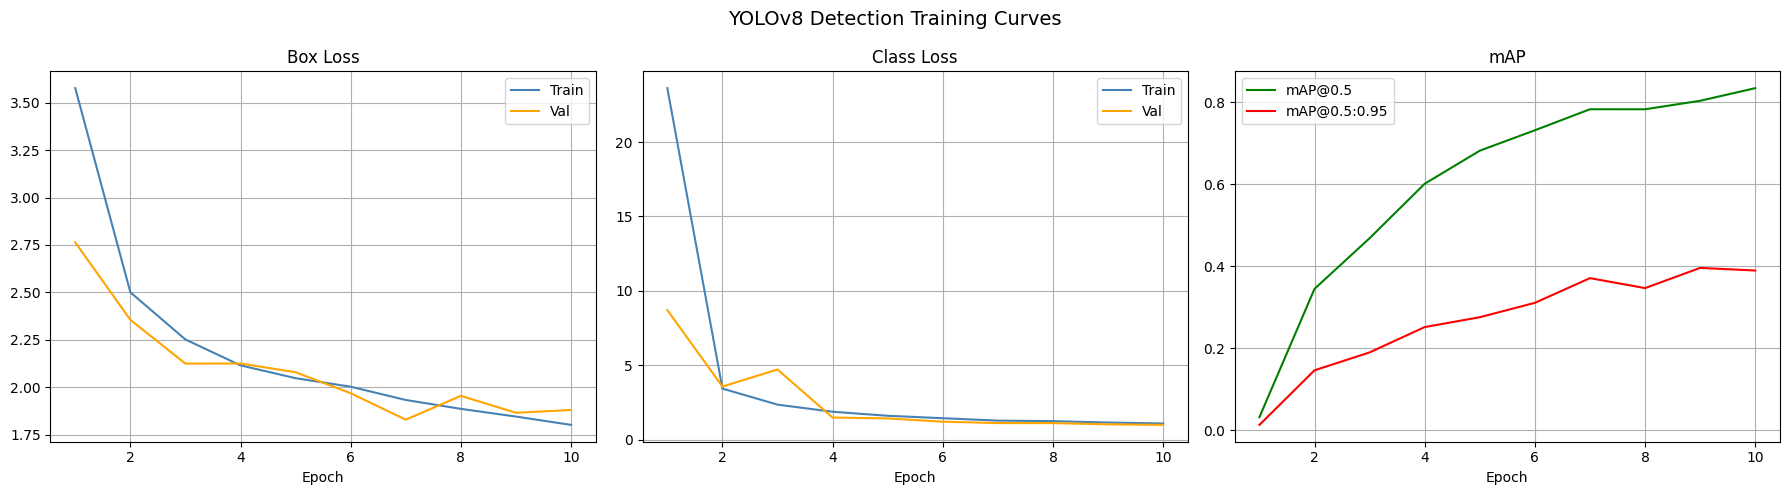

In [ ]:
if os.path.exists(results_csv):
    res_df = pd.read_csv(results_csv)
    res_df.columns = res_df.columns.str.strip()
    res_df = res_df.apply(pd.to_numeric, errors='coerce').dropna()
    print(f"Loaded results.csv with {len(res_df)} epoch rows.")
else:
    raise FileNotFoundError(f"results.csv not found at {results_csv}.")

epochs_range = res_df['epoch']
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(epochs_range, res_df['train/box_loss'], label='Train', color='steelblue')
axs[0].plot(epochs_range, res_df['val/box_loss'],   label='Val',   color='orange')
axs[0].set_title('Box Loss'); axs[0].set_xlabel('Epoch'); axs[0].legend(); axs[0].grid(True)

axs[1].plot(epochs_range, res_df['train/cls_loss'], label='Train', color='steelblue')
axs[1].plot(epochs_range, res_df['val/cls_loss'],   label='Val',   color='orange')
axs[1].set_title('Class Loss'); axs[1].set_xlabel('Epoch'); axs[1].legend(); axs[1].grid(True)

axs[2].plot(epochs_range, res_df['metrics/mAP50(B)'],    label='mAP@0.5',      color='green')
axs[2].plot(epochs_range, res_df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', color='red')
axs[2].set_title('mAP'); axs[2].set_xlabel('Epoch'); axs[2].legend(); axs[2].grid(True)

plt.suptitle('YOLOv8 Detection Training Curves', fontsize=14)
plt.tight_layout(); plt.show()

## 8. Stage 2 — Fine-tune Siamese Twin Network with Contrastive Loss

Stage 2 — Siamese fine-tuning (triplet + cross-entropy combined loss)
  Hooked layer-9 feature channels : 512
  Trainable parameters : 11,412,456
  Epoch   1/30 | total=1.2480  triplet=0.3621  ce=1.7719  val=1.2103  lr=9.97e-05
  Epoch   2/30 | total=1.1493  triplet=0.2911  ce=1.7165  val=1.0906  lr=9.89e-05
  Epoch   3/30 | total=1.0904  triplet=0.2586  ce=1.6635  val=1.2410  lr=9.76e-05
  Epoch   4/30 | total=1.0311  triplet=0.2233  ce=1.6157  val=1.1501  lr=9.57e-05
  Epoch   5/30 | total=1.0012  triplet=0.2149  ce=1.5727  val=0.9724  lr=9.34e-05
  Epoch   6/30 | total=0.9566  triplet=0.1907  ce=1.5316  val=0.8642  lr=9.05e-05
  Epoch   7/30 | total=0.8972  triplet=0.1531  ce=1.4882  val=0.8701  lr=8.73e-05
  Epoch   8/30 | total=0.8430  triplet=0.1216  ce=1.4428  val=0.9037  lr=8.36e-05
  Epoch   9/30 | total=0.8280  triplet=0.1277  ce=1.4006  val=0.8112  lr=7.96e-05
  Epoch  10/30 | total=0.7861  triplet=0.1089  ce=1.3544  val=0.7684  lr=7.52e-05
  Epoch  11/30 | total=0.7727  tri

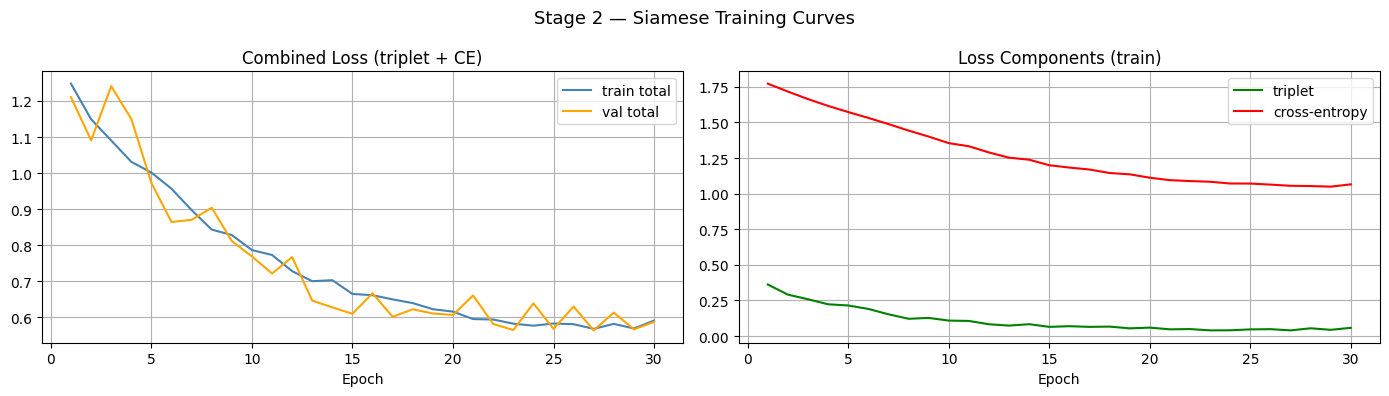

In [ ]:
print("Stage 2 — Siamese fine-tuning (triplet + cross-entropy combined loss)")

# Build the Siamese model on top of the trained YOLOv8 detector
siamese_net = SiameseYOLOv8(model_best, embed_dim=EMBED_DIM,
                             num_classes=NUM_CLASSES).to(DEVICE)

# Only update parameters that require grad (backbone layers 4-9 + heads)
trainable = [p for p in siamese_net.parameters() if p.requires_grad]
print(f"  Trainable parameters : {sum(p.numel() for p in trainable):,}")

optimizer = torch.optim.AdamW(trainable, lr=SIAMESE_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=SIAMESE_EPOCHS, eta_min=1e-6
)

best_val_loss = float('inf')
best_state    = None
train_losses, val_losses     = [], []
train_t_losses, train_ce_losses = [], []

for epoch in range(1, SIAMESE_EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────────────────────
    siamese_net.train()
    run_total = run_t = run_ce = 0.0

    for anchor, positive, negative, anc_labels in train_triplet_loader:
        anchor     = anchor.to(DEVICE)
        positive   = positive.to(DEVICE)
        negative   = negative.to(DEVICE)
        anc_labels = anc_labels.to(DEVICE)

        # Single forward pass per image (embeddings + logits for anchor)
        anc_emb, anc_logits = siamese_net.extract_with_logits(anchor)
        pos_emb              = siamese_net.extract(positive)
        neg_emb              = siamese_net.extract(negative)

        loss, t_loss, ce_loss = combined_loss(
            anc_emb, pos_emb, neg_emb,
            anc_logits, anc_labels,
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
        optimizer.step()

        run_total += loss.item()
        run_t     += t_loss.item()
        run_ce    += ce_loss.item()

    n = len(train_triplet_loader)
    avg_train    = run_total / n
    avg_t_loss   = run_t    / n
    avg_ce_loss  = run_ce   / n
    train_losses.append(avg_train)
    train_t_losses.append(avg_t_loss)
    train_ce_losses.append(avg_ce_loss)

    # ── Validation ────────────────────────────────────────────────────────────
    siamese_net.eval()
    val_run = 0.0
    with torch.no_grad():
        for anchor, positive, negative, anc_labels in val_triplet_loader:
            anchor     = anchor.to(DEVICE)
            positive   = positive.to(DEVICE)
            negative   = negative.to(DEVICE)
            anc_labels = anc_labels.to(DEVICE)

            anc_emb, anc_logits = siamese_net.extract_with_logits(anchor)
            pos_emb              = siamese_net.extract(positive)
            neg_emb              = siamese_net.extract(negative)

            loss, _, _ = combined_loss(anc_emb, pos_emb, neg_emb,
                                       anc_logits, anc_labels)
            val_run += loss.item()

    avg_val = val_run / max(len(val_triplet_loader), 1)
    val_losses.append(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_state    = {k: v.cpu().clone() for k, v in siamese_net.state_dict().items()}

    scheduler.step()
    print(f"  Epoch {epoch:3d}/{SIAMESE_EPOCHS} | "
          f"total={avg_train:.4f}  triplet={avg_t_loss:.4f}  "
          f"ce={avg_ce_loss:.4f}  val={avg_val:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}")

# Restore best weights
if best_state is not None:
    siamese_net.load_state_dict(best_state)
    print(f"\n✅ Restored best weights (val_loss={best_val_loss:.4f})")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ep = range(1, SIAMESE_EPOCHS + 1)

axes[0].plot(ep, train_losses, label='train total', color='steelblue')
axes[0].plot(ep, val_losses,   label='val total',   color='orange')
axes[0].set_title('Combined Loss (triplet + CE)'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(ep, train_t_losses,  label='triplet', color='green')
axes[1].plot(ep, train_ce_losses, label='cross-entropy', color='red')
axes[1].set_title('Loss Components (train)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Stage 2 — Siamese Training Curves', fontsize=13)
plt.tight_layout()
plt.show()


## 9. Build Support Set (Reference Embeddings per Class)

In [ ]:
def build_prototypes(k: int = None, verbose: bool = True) -> dict:
    """
    Build one mean-prototype embedding per defect class from YOLO-cropped
    training images.

    Parameters
    ----------
    k : int or None
        Number of support images per class (K-shot).
        None = use ALL available training images (full-shot baseline).
    verbose : bool
        Print per-class stats table when True.

    Returns
    -------
    dict[int, torch.Tensor]   class_idx → L2-normalised prototype (EMBED_DIM,)
    """
    train_img_dir = os.path.join(output_dir, 'images/train')
    train_lbl_dir = os.path.join(output_dir, 'labels/train')

    # ── Gather all training image paths per class ─────────────────────────────
    class_to_paths: dict[int, list] = {i: [] for i in range(NUM_CLASSES)}
    for fname in sorted(os.listdir(train_img_dir)):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        stem  = os.path.splitext(fname)[0]
        lpath = os.path.join(train_lbl_dir, stem + '.txt')
        if not os.path.exists(lpath):
            continue
        with open(lpath) as f:
            lines = [l.strip() for l in f if l.strip()]
        if not lines:
            continue
        cls = Counter(int(l.split()[0]) for l in lines).most_common(1)[0][0]
        class_to_paths[cls].append(os.path.join(train_img_dir, fname))

    # ── Sample K images per class (or all if k is None) ───────────────────────
    class_embeddings: dict[int, list] = {}
    siamese_net.eval()
    with torch.no_grad():
        for cls_idx, paths in class_to_paths.items():
            if not paths:
                continue
            selected = paths if k is None else random.sample(paths, min(k, len(paths)))
            embs = []
            for img_path in selected:
                crop_t = crop_image(img_path, _crop_detector)
                emb    = siamese_net.extract(crop_t.unsqueeze(0).to(DEVICE))
                embs.append(emb.squeeze(0).cpu())
            class_embeddings[cls_idx] = embs

    # ── Mean prototype + re-normalise ─────────────────────────────────────────
    prototypes: dict[int, torch.Tensor] = {}
    if verbose:
        label_k = 'all' if k is None else str(k)
        print(f"\n── Prototypes (k={label_k}) ──────────────────────────────────")
        print(f"  {'Class':<20}  {'#imgs':>5}  {'intra-var':>10}  proto-norm")
        print("  " + "-" * 52)

    for cls_idx in range(NUM_CLASSES):
        embs = class_embeddings.get(cls_idx, [])
        if not embs:
            continue
        stack    = torch.stack(embs, dim=0)
        mean_emb = stack.mean(dim=0)
        proto    = F.normalize(mean_emb, p=2, dim=0)
        prototypes[cls_idx] = proto

        if verbose:
            intra_var = ((stack - proto.unsqueeze(0)).pow(2).sum(dim=1)).mean().item()
            print(f"  {CLASSES[cls_idx]:<20}  {len(embs):>5}  {intra_var:>10.4f}  "
                  f"{proto.norm().item():.4f}")

    if verbose:
        print(f"\n  Built {len(prototypes)} prototypes.")
    return prototypes


# ── Build the default full-shot prototypes used by the rest of the notebook ────
support_prototypes = build_prototypes(k=None, verbose=True)



── Prototypes (k=all) ──────────────────────────────────
  Class                 #imgs   intra-var  proto-norm
  ----------------------------------------------------
  missing_hole             92      0.0074  1.0000
  mouse_bite               95      0.1258  1.0000
  open_circuit             96      0.1481  1.0000
  short                    90      0.0631  1.0000
  spur                     84      0.0907  1.0000
  spurious_copper          97      0.1176  1.0000

  Built 6 prototypes.


## 10. Run Inference on Test Set (YOLOv8 Detection + Siamese Classification)

In [ ]:
def get_gt_class(image_name: str, label_dir: str):
    """Return dominant ground-truth class index (int) or None."""
    stem  = os.path.splitext(image_name)[0]
    lpath = os.path.join(label_dir, stem + '.txt')
    if not os.path.exists(lpath):
        return None
    with open(lpath) as f:
        lines = [l.strip() for l in f if l.strip()]
    if not lines:
        return None
    return Counter(int(l.split()[0]) for l in lines).most_common(1)[0][0]


def siamese_classify(img_path: str) -> int:
    """
    Classify via the trained cross-entropy head (primary) using a YOLO crop.

    Pipeline:
      1. Crop the highest-confidence YOLO-detected defect region.
      2. Embed the crop through the shared backbone + EmbeddingHead.
      3. Pass embedding through ClassificationHead → argmax class.

    Using the CE head (trained jointly with triplet loss) directly is more
    accurate than nearest-prototype because it learned a direct decision
    boundary during Stage 2 training.

    Falls back to nearest-prototype cosine matching if prototypes are available
    and CE confidence is low.
    """
    crop_tensor = crop_image(img_path, _crop_detector)
    img_tensor  = crop_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        emb, logits = siamese_net.extract_with_logits(img_tensor)

    # ── Primary: CE head argmax ───────────────────────────────────────────────
    probs    = torch.softmax(logits, dim=1)
    ce_conf, ce_pred = probs.max(dim=1)
    ce_pred  = ce_pred.item()
    ce_conf  = ce_conf.item()

    # ── Fallback: nearest-prototype cosine similarity (if CE confidence < 0.4) ─
    if ce_conf < 0.4 and support_prototypes:
        qry_emb  = emb.squeeze(0).cpu()
        best_cls, best_sim = -1, -float('inf')
        for cls_idx, proto in support_prototypes.items():
            sim = torch.dot(qry_emb, proto).item()
            if sim > best_sim:
                best_sim, best_cls = sim, cls_idx
        return best_cls

    return ce_pred


# ── Evaluate on test set ──────────────────────────────────────────────────────
test_img_dir   = os.path.join(output_dir, 'images/test')
test_label_dir = os.path.join(output_dir, 'labels/test')
test_images    = sorted(
    f for f in os.listdir(test_img_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
)

# det_model used for YOLOv8 evaluation AND as crop detector for Siamese
det_model = YOLO(best_weights)

y_true, y_pred_yolo, y_pred_siamese = [], [], []

for img_name in test_images:
    gt = get_gt_class(img_name, test_label_dir)
    if gt is None:
        continue

    img_path = os.path.join(test_img_dir, img_name)

    # ── YOLOv8 detection-based prediction ────────────────────────────────────
    result = det_model(img_path, imgsz=IMG_SIZE, conf=CONF_THRESH, verbose=False)[0]
    boxes  = result.boxes
    if boxes is not None and len(boxes) > 0:
        confs   = boxes.conf.cpu().numpy()
        cls_ids = boxes.cls.cpu().numpy().astype(int)
        mask    = confs >= CONF_THRESH
        yolo_pred = int(cls_ids[mask][confs[mask].argmax()]) if mask.any() else -1
    else:
        yolo_pred = -1

    # ── Siamese: crop → CE head (with proto fallback) ────────────────────────
    siam_pred = siamese_classify(img_path)

    y_true.append(gt)
    y_pred_yolo.append(yolo_pred)
    y_pred_siamese.append(siam_pred)

print(f"Test images evaluated : {len(y_true)}")
print(f"YOLOv8  detections    : {sum(p != -1 for p in y_pred_yolo)}")
print(f"Siamese predictions   : {sum(p != -1 for p in y_pred_siamese)}")


Test images evaluated : 70
YOLOv8  detections    : 60
Siamese predictions   : 70


## 11. Accuracy

In [ ]:
# ── YOLOv8-only accuracy (baseline, same method as simple notebook) ───────────
paired_yolo     = [(gt, pr) for gt, pr in zip(y_true, y_pred_yolo)     if pr != -1]
y_true_yolo     = [p[0] for p in paired_yolo]
y_pred_yolo_f   = [p[1] for p in paired_yolo]
acc_yolo        = accuracy_score(y_true_yolo, y_pred_yolo_f)

# ── Siamese accuracy ──────────────────────────────────────────────────────────
paired_siam     = [(gt, pr) for gt, pr in zip(y_true, y_pred_siamese)  if pr != -1]
y_true_siam     = [p[0] for p in paired_siam]
y_pred_siam_f   = [p[1] for p in paired_siam]
acc_siam        = accuracy_score(y_true_siam, y_pred_siam_f)

print("=" * 60)
print(f"  YOLOv8  Detection Accuracy  : {acc_yolo * 100:.2f}%  "
      f"({len(y_true_yolo)}/{len(y_true)} detected)")
print(f"  Siamese Classification Acc  : {acc_siam * 100:.2f}%  "
      f"({len(y_true_siam)}/{len(y_true)} classified)")
print("=" * 60)

  YOLOv8  Detection Accuracy  : 100.00%  (60/70 detected)
  Siamese Classification Acc  : 91.43%  (70/70 classified)


## 12. Confusion Matrices

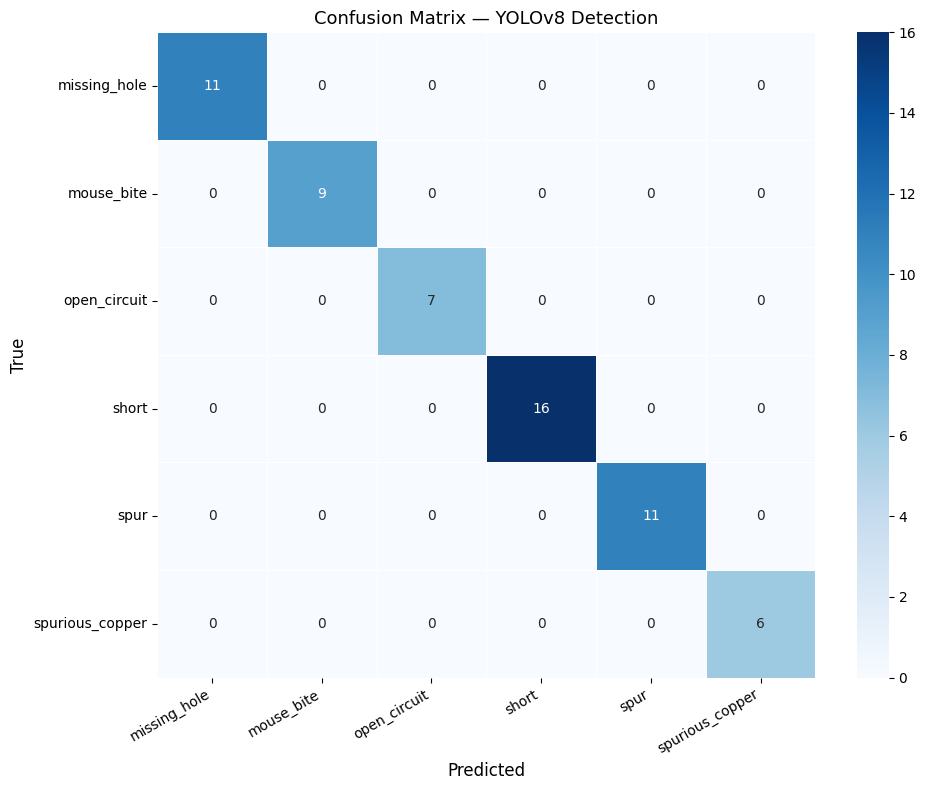

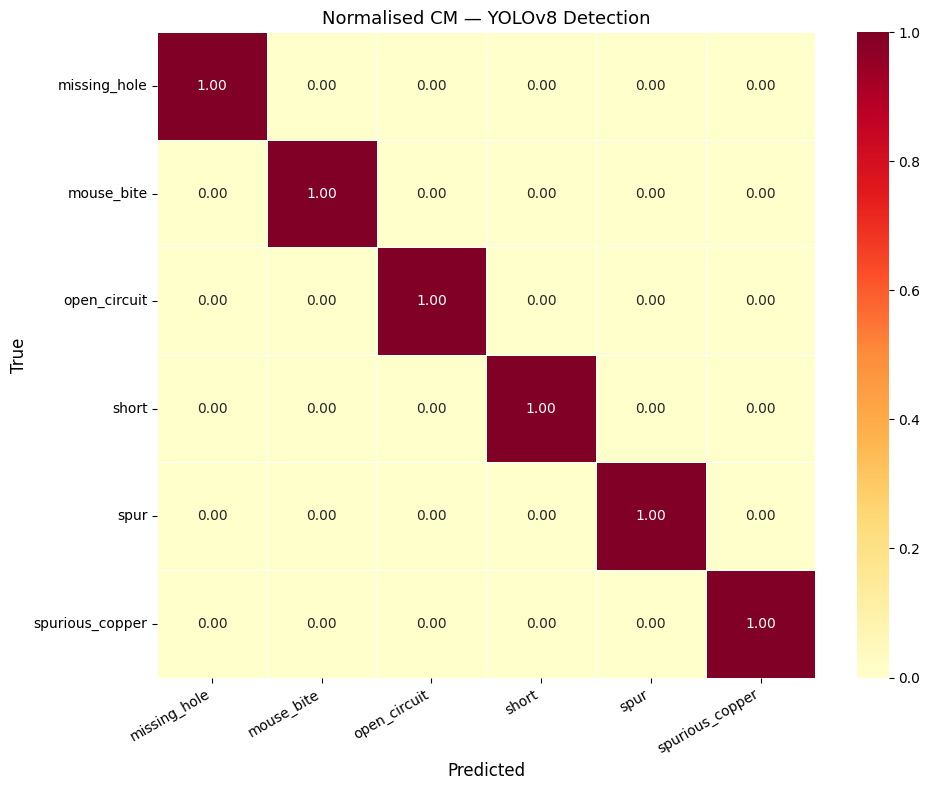

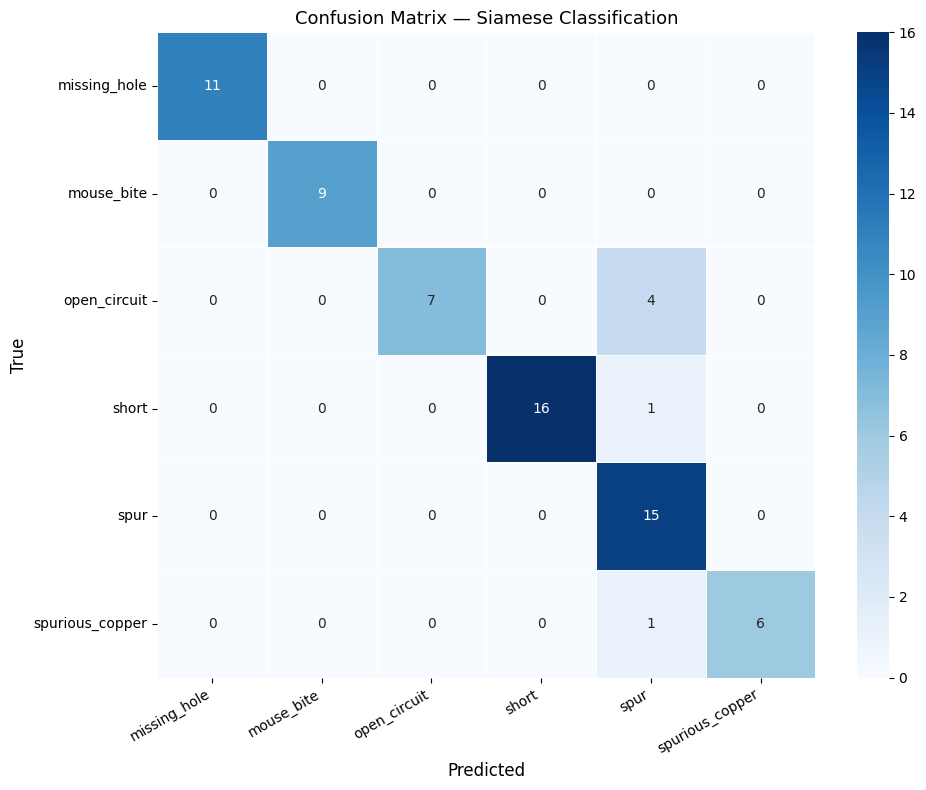

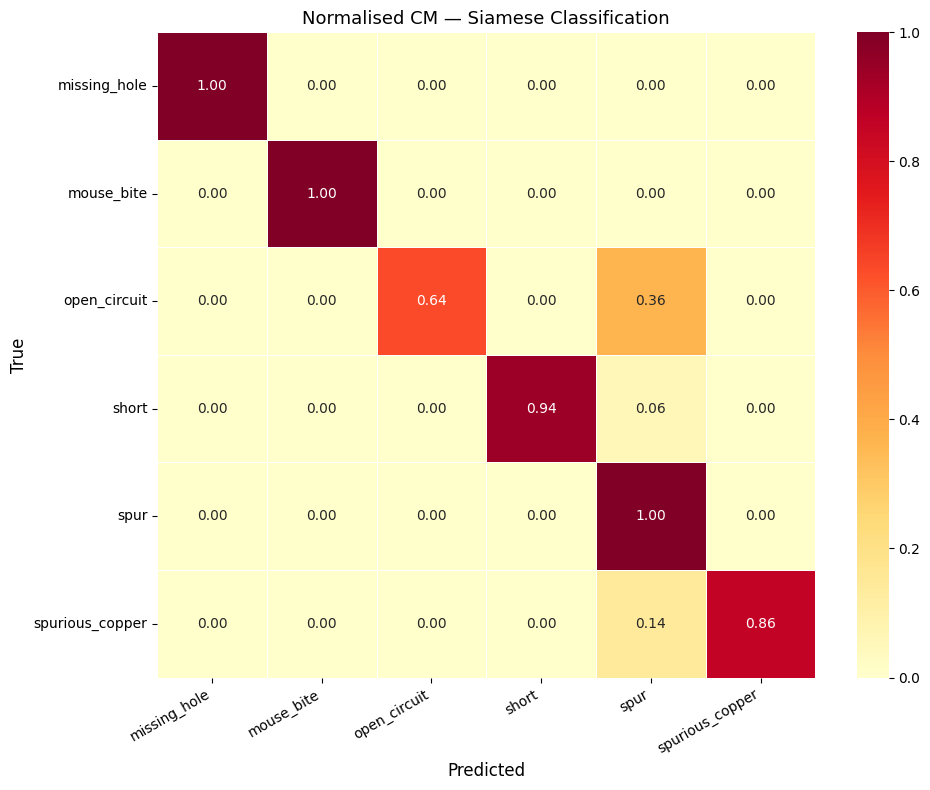

In [ ]:
def plot_cm(y_t, y_p, title, cmap='Blues', normalise=False):
    labels  = sorted(set(y_t) | set(y_p))
    names   = [CLASSES[i] for i in labels]
    cm      = confusion_matrix(y_t, y_p, labels=labels,
                               normalize='true' if normalise else None)
    fmt     = '.2f' if normalise else 'd'
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=names, yticklabels=names,
                linewidths=0.5, vmin=0, vmax=1 if normalise else None, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True',      fontsize=12)
    ax.set_title(title, fontsize=13)
    plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

# ── YOLOv8 confusion matrices ─────────────────────────────────────────────────
plot_cm(y_true_yolo, y_pred_yolo_f,
        'Confusion Matrix — YOLOv8 Detection',    cmap='Blues')
plot_cm(y_true_yolo, y_pred_yolo_f,
        'Normalised CM — YOLOv8 Detection',       cmap='YlOrRd', normalise=True)

# ── Siamese confusion matrices ────────────────────────────────────────────────
plot_cm(y_true_siam, y_pred_siam_f,
        'Confusion Matrix — Siamese Classification',   cmap='Blues')
plot_cm(y_true_siam, y_pred_siam_f,
        'Normalised CM — Siamese Classification',      cmap='YlOrRd', normalise=True)

## 13. Classification Reports

In [ ]:
def styled_report(y_t, y_p, title):
    labels  = sorted(set(y_t) | set(y_p))
    names   = [CLASSES[i] for i in labels]
    rstr    = classification_report(y_t, y_p, labels=labels, target_names=names, digits=4)
    print(f"\n{'='*65}")
    print(f"  {title}")
    print('='*65)
    print(rstr)

    rdict = classification_report(y_t, y_p, labels=labels, target_names=names,
                                  digits=4, output_dict=True)
    rdf = pd.DataFrame(rdict).T
    rdf['support'] = rdf['support'].astype(int)
    return (
        rdf.style
        .format({'precision': '{:.4f}', 'recall': '{:.4f}', 'f1-score': '{:.4f}'})
        .background_gradient(cmap='RdYlGn', subset=['precision', 'recall', 'f1-score'])
        .set_caption(title)
        .set_table_styles([{'selector': 'caption',
                            'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    ), rdict

print("── YOLOv8 Detection Report ──────────────────────────────────────────────")
styled_yolo, rdict_yolo = styled_report(y_true_yolo, y_pred_yolo_f, "YOLOv8 Detection — Classification Report")
styled_yolo

── YOLOv8 Detection Report ──────────────────────────────────────────────

  YOLOv8 Detection — Classification Report
                 precision    recall  f1-score   support

   missing_hole     1.0000    1.0000    1.0000        11
     mouse_bite     1.0000    1.0000    1.0000         9
   open_circuit     1.0000    1.0000    1.0000         7
          short     1.0000    1.0000    1.0000        16
           spur     1.0000    1.0000    1.0000        11
spurious_copper     1.0000    1.0000    1.0000         6

       accuracy                         1.0000        60
      macro avg     1.0000    1.0000    1.0000        60
   weighted avg     1.0000    1.0000    1.0000        60



,precision,recall,f1-score,support
missing_hole,1.0000,1.0000,1.0000,11
mouse_bite,1.0000,1.0000,1.0000,9
open_circuit,1.0000,1.0000,1.0000,7
short,1.0000,1.0000,1.0000,16
spur,1.0000,1.0000,1.0000,11
spurious_copper,1.0000,1.0000,1.0000,6
accuracy,1.0000,1.0000,1.0000,1
macro avg,1.0000,1.0000,1.0000,60
weighted avg,1.0000,1.0000,1.0000,60


In [ ]:
print("── Siamese Classification Report ────────────────────────────────────────")
styled_siam, rdict_siam = styled_report(y_true_siam, y_pred_siam_f, "Siamese Network — Classification Report")
styled_siam

── Siamese Classification Report ────────────────────────────────────────

  Siamese Network — Classification Report
                 precision    recall  f1-score   support

   missing_hole     1.0000    1.0000    1.0000        11
     mouse_bite     1.0000    1.0000    1.0000         9
   open_circuit     1.0000    0.6364    0.7778        11
          short     1.0000    0.9412    0.9697        17
           spur     0.7143    1.0000    0.8333        15
spurious_copper     1.0000    0.8571    0.9231         7

       accuracy                         0.9143        70
      macro avg     0.9524    0.9058    0.9173        70
   weighted avg     0.9388    0.9143    0.9143        70



,precision,recall,f1-score,support
missing_hole,1.0000,1.0000,1.0000,11
mouse_bite,1.0000,1.0000,1.0000,9
open_circuit,1.0000,0.6364,0.7778,11
short,1.0000,0.9412,0.9697,17
spur,0.7143,1.0000,0.8333,15
spurious_copper,1.0000,0.8571,0.9231,7
accuracy,0.9143,0.9143,0.9143,0
macro avg,0.9524,0.9058,0.9173,70
weighted avg,0.9388,0.9143,0.9143,70


## 14. Per-Class F1 Bar Chart (YOLOv8 vs Siamese)

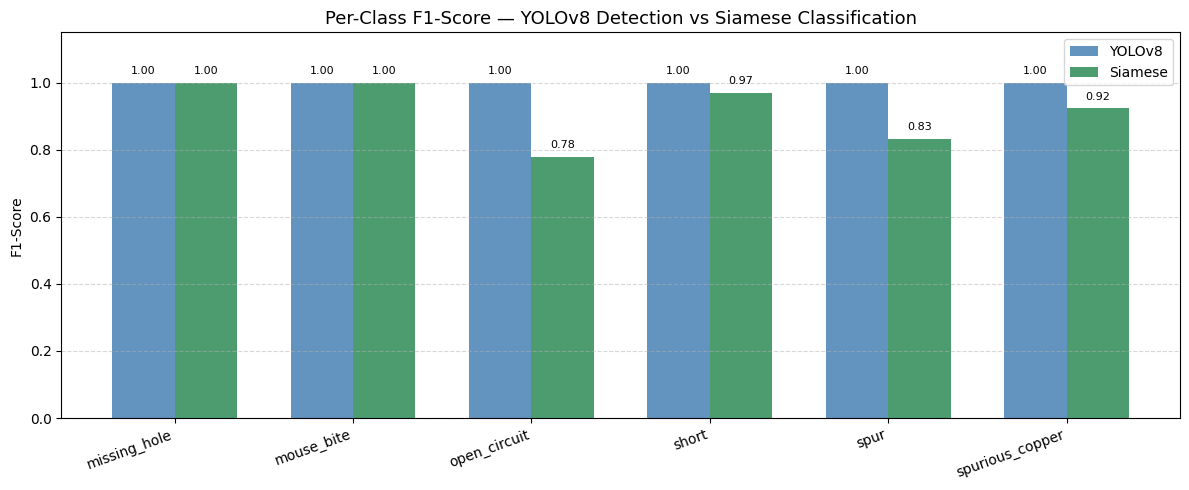

In [ ]:
all_cls = sorted(set(y_true_yolo) | set(y_true_siam))
cls_names = [CLASSES[i] for i in all_cls]

f1_yolo   = [rdict_yolo.get(CLASSES[i], {}).get('f1-score', 0)  for i in all_cls]
f1_siam   = [rdict_siam.get(CLASSES[i], {}).get('f1-score', 0)  for i in all_cls]

x = np.arange(len(cls_names))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_y = ax.bar(x - w/2, f1_yolo, w, label='YOLOv8',  color='steelblue',  alpha=0.85)
bars_s = ax.bar(x + w/2, f1_siam, w, label='Siamese', color='seagreen',   alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(cls_names, rotation=20, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1-Score — YOLOv8 Detection vs Siamese Classification', fontsize=13)
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)

for bars in [bars_y, bars_s]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout(); plt.show()

## 15. Sample Predictions Visualisation

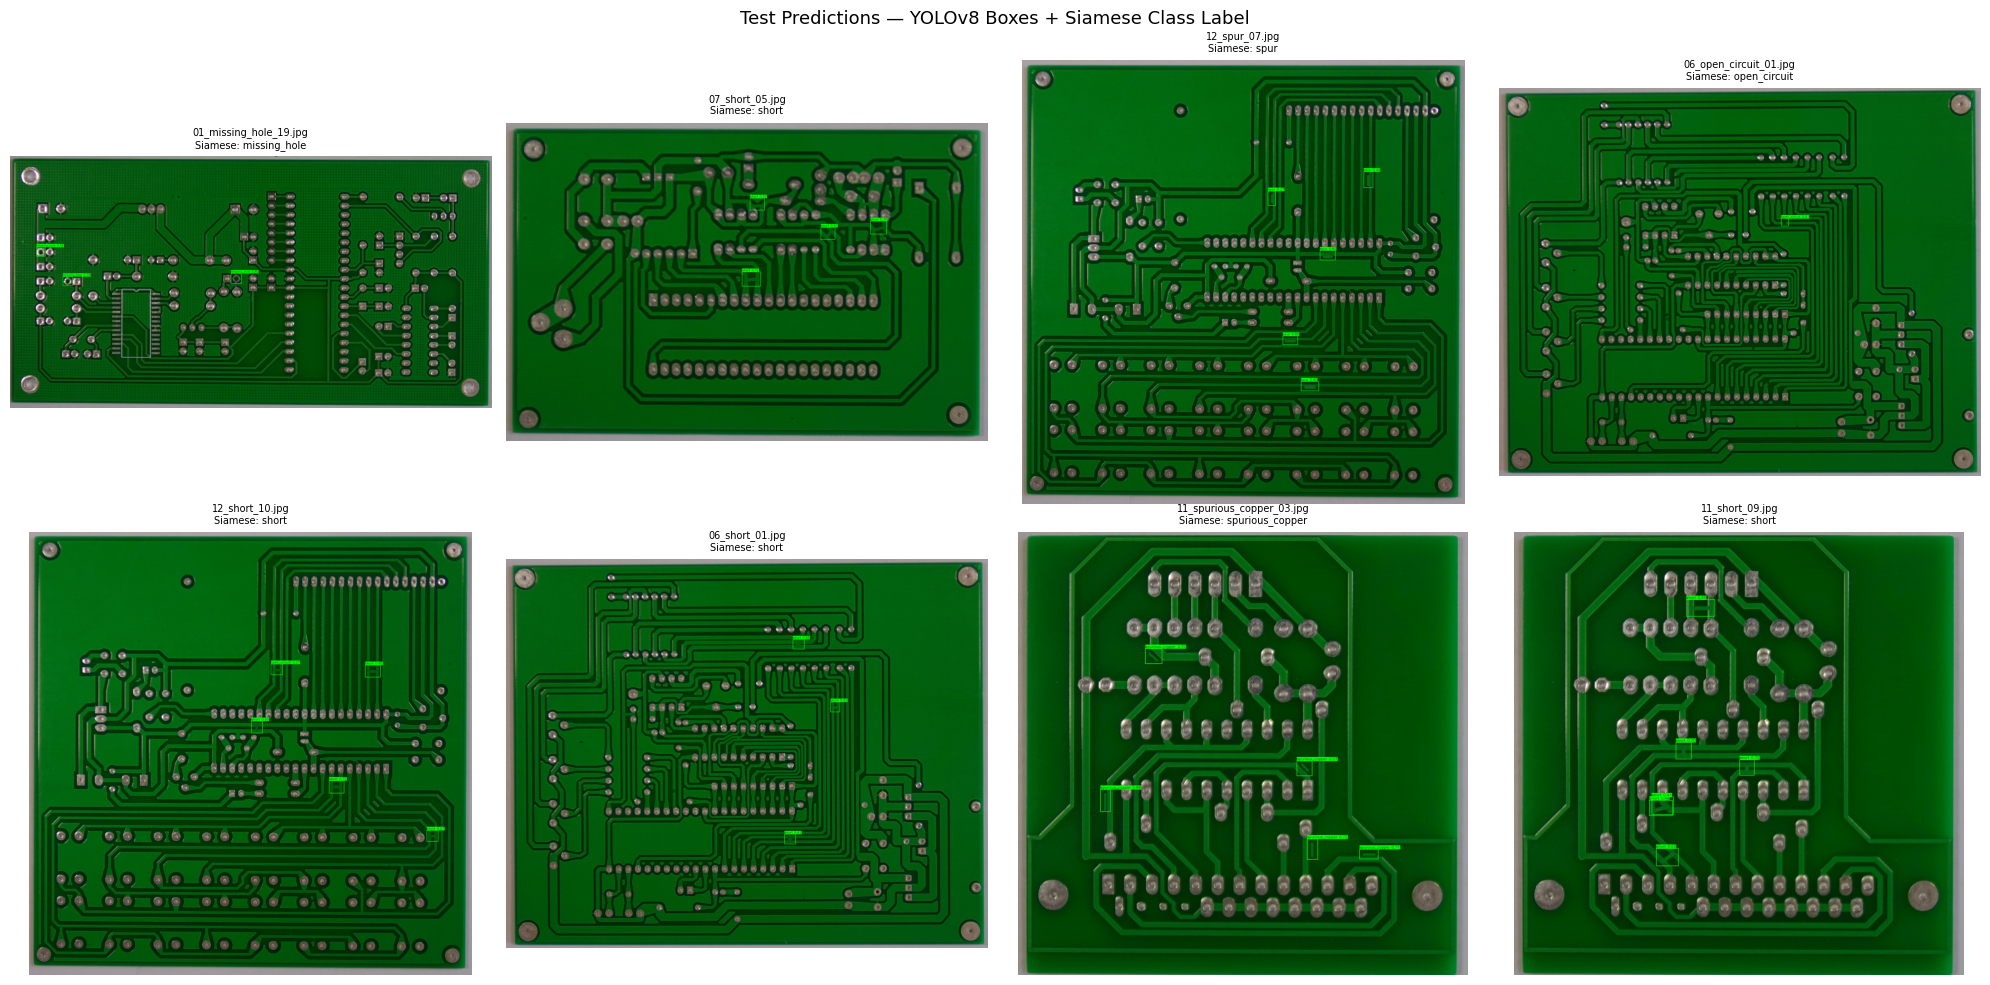

In [ ]:
def draw_boxes(bgr, boxes_obj, class_names, color=(0, 255, 0)):
    img = bgr.copy()
    if boxes_obj is None or len(boxes_obj) == 0:
        return img
    for box in boxes_obj:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        ci   = int(box.cls.cpu().numpy()[0])
        conf = float(box.conf.cpu().numpy()[0])
        lbl  = f"{class_names[ci]} {conf:.2f}"
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        (tw, th), _ = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(img, (x1, y1-th-6), (x1+tw, y1), color, -1)
        cv2.putText(img, lbl, (x1, y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1)
    return img

sample_imgs = random.sample(test_images, min(8, len(test_images)))
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, img_name in zip(axes.flat, sample_imgs):
    img_path   = os.path.join(test_img_dir, img_name)
    bgr        = cv2.imread(img_path)
    result     = det_model(img_path, imgsz=IMG_SIZE, conf=CONF_THRESH, verbose=False)[0]
    drawn      = draw_boxes(bgr, result.boxes, CLASSES)
    siam_cls   = siamese_classify(img_path)
    siam_label = CLASSES[siam_cls] if siam_cls != -1 else 'none'
    ax.imshow(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{img_name}\nSiamese: {siam_label}", fontsize=7)
    ax.axis('off')

plt.suptitle('Test Predictions — YOLOv8 Boxes + Siamese Class Label', fontsize=13)
plt.tight_layout(); plt.show()

## 16. Summary

In [ ]:
ma_yolo = rdict_yolo.get('macro avg', {})
ma_siam = rdict_siam.get('macro avg', {})

print("╔══════════════════════════════════════════════════════════════╗")
print("║     PCB Defect Detection — Siamese + YOLOv8 Summary          ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Backbone         : YOLOv8s (yolov8s.pt)                    ║")
print(f"║  Detection epochs : {EPOCHS:<41} ║")
print(f"║  Siamese epochs   : {SIAMESE_EPOCHS:<41} ║")
print(f"║  Embed dim        : {EMBED_DIM:<41} ║")
print(f"║  Classes          : {NUM_CLASSES:<41} ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║              {'YOLOv8':>12}    {'Siamese':>12}                ║")
print(f"║  Accuracy  : {acc_yolo*100:>10.2f}%  {acc_siam*100:>10.2f}%                ║")
print(f"║  Macro P   : {ma_yolo.get('precision',0):>12.4f}  {ma_siam.get('precision',0):>12.4f}                ║")
print(f"║  Macro R   : {ma_yolo.get('recall',0):>12.4f}  {ma_siam.get('recall',0):>12.4f}                ║")
print(f"║  Macro F1  : {ma_yolo.get('f1-score',0):>12.4f}  {ma_siam.get('f1-score',0):>12.4f}                ║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║     PCB Defect Detection — Siamese + YOLOv8 Summary          ║
╠══════════════════════════════════════════════════════════════╣
║  Backbone         : YOLOv8s (yolov8s.pt)                    ║
║  Detection epochs : 10                                        ║
║  Siamese epochs   : 30                                        ║
║  Embed dim        : 256                                       ║
║  Classes          : 6                                         ║
╠══════════════════════════════════════════════════════════════╣
║                    YOLOv8         Siamese                ║
║  Accuracy  :     100.00%       91.43%                ║
║  Macro P   :       1.0000        0.9524                ║
║  Macro R   :       1.0000        0.9058                ║
║  Macro F1  :       1.0000        0.9173                ║
╚══════════════════════════════════════════════════════════════╝


## 17. K-Shot Prototype Evaluation

Evaluate the Siamese network across **K = 1, 3, 5, 10, 20, all** support images per class.

| K | Prototype built from |
|---|---|
| 1 | 1 randomly sampled image per class |
| 3 | 3 randomly sampled images per class |
| 5 | 5 randomly sampled images per class |
| 10 | 10 randomly sampled images per class |
| 20 | 20 randomly sampled images per class |
| all | every training image (full-shot baseline — current default) |

For each K:
- Build prototypes from K training crops per class.
- Run inference on the **same fixed test set** using the CE head (with prototype fallback).
- Record accuracy and macro-F1.
- Plot accuracy and macro-F1 vs K to find the best K value.


In [ ]:
def evaluate_k_shot(k, protos, n_repeats: int = 3) -> dict:
    """
    Evaluate the Siamese model on the test set using prototypes built from
    k support images per class.

    Parameters
    ----------
    k        : int or None — number of support shots per class
    protos   : dict returned by build_prototypes(k)
    n_repeats: for stochastic k (random sampling), repeat and average

    Returns dict with keys: accuracy, macro_f1, macro_p, macro_r
    """
    accs, f1s, ps, rs = [], [], [], []

    for _ in range(n_repeats):
        cur_protos = build_prototypes(k=k, verbose=False) if k is not None else protos

        yt, yp = [], []
        for img_name in test_images:
            gt = get_gt_class(img_name, test_label_dir)
            if gt is None:
                continue

            img_path    = os.path.join(test_img_dir, img_name)
            crop_tensor = crop_image(img_path, _crop_detector)
            img_tensor  = crop_tensor.unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                emb, logits = siamese_net.extract_with_logits(img_tensor)

            # Primary: CE head
            probs           = torch.softmax(logits, dim=1)
            ce_conf, ce_cls = probs.max(dim=1)
            pred            = ce_cls.item()

            # Fallback: nearest prototype (if CE confidence < 0.4)
            if ce_conf.item() < 0.4 and cur_protos:
                qry_emb  = emb.squeeze(0).cpu()
                best_cls, best_sim = -1, -float('inf')
                for cls_idx, proto in cur_protos.items():
                    sim = torch.dot(qry_emb, proto).item()
                    if sim > best_sim:
                        best_sim, best_cls = sim, cls_idx
                pred = best_cls

            yt.append(gt)
            yp.append(pred)

        rdict = classification_report(yt, yp, labels=list(range(NUM_CLASSES)),
                                      target_names=CLASSES, digits=4,
                                      output_dict=True, zero_division=0)
        accs.append(accuracy_score(yt, yp) * 100)
        f1s.append(rdict['macro avg']['f1-score'] * 100)
        ps.append(rdict['macro avg']['precision'] * 100)
        rs.append(rdict['macro avg']['recall'] * 100)

    return {
        'accuracy': np.mean(accs),
        'macro_f1': np.mean(f1s),
        'macro_p':  np.mean(ps),
        'macro_r':  np.mean(rs),
        'acc_std':  np.std(accs),
        'f1_std':   np.std(f1s),
    }


# ── K-shot sweep ──────────────────────────────────────────────────────────────
K_VALUES   = [1, 3, 5, 10, 20, None]   # None = all training images
K_LABELS   = ['K=1', 'K=3', 'K=5', 'K=10', 'K=20', 'K=all']
N_REPEATS  = 5    # average over 5 random samplings per K (reduces variance)

kshot_results = {}

print(f"{'K':>6}  {'Accuracy':>10}  {'±':>6}  {'Macro-F1':>10}  {'±':>6}  "
      f"{'Macro-P':>10}  {'Macro-R':>10}")
print("-" * 70)

for k, label in zip(K_VALUES, K_LABELS):
    reps = 1 if k is None else N_REPEATS    # all-shot is deterministic
    res  = evaluate_k_shot(k, support_prototypes, n_repeats=reps)
    kshot_results[label] = res
    print(f"  {label:>5}  {res['accuracy']:>9.2f}%  "
          f"{res['acc_std']:>5.2f}  {res['macro_f1']:>9.2f}%  "
          f"{res['f1_std']:>5.2f}  {res['macro_p']:>9.2f}%  "
          f"{res['macro_r']:>9.2f}%")

# ── Find best K ───────────────────────────────────────────────────────────────
best_label = max(kshot_results, key=lambda l: kshot_results[l]['accuracy'])
best_res   = kshot_results[best_label]
print(f"\n🏆 Best K = {best_label}  →  "
      f"Accuracy {best_res['accuracy']:.2f}%  |  Macro-F1 {best_res['macro_f1']:.2f}%")


     K    Accuracy       ±    Macro-F1       ±     Macro-P     Macro-R
----------------------------------------------------------------------
    K=1      90.29%   2.29      90.47%   2.53      93.86%      89.94%
    K=3      87.71%   2.49      87.99%   2.69      91.18%      87.93%
    K=5      91.43%   0.00      91.73%   0.00      95.24%      90.58%
   K=10      91.43%   0.00      91.73%   0.00      95.24%      90.58%
   K=20      91.43%   0.00      91.73%   0.00      95.24%      90.58%
  K=all      91.43%   0.00      91.73%   0.00      95.24%      90.58%

🏆 Best K = K=5  →  Accuracy 91.43%  |  Macro-F1 91.73%


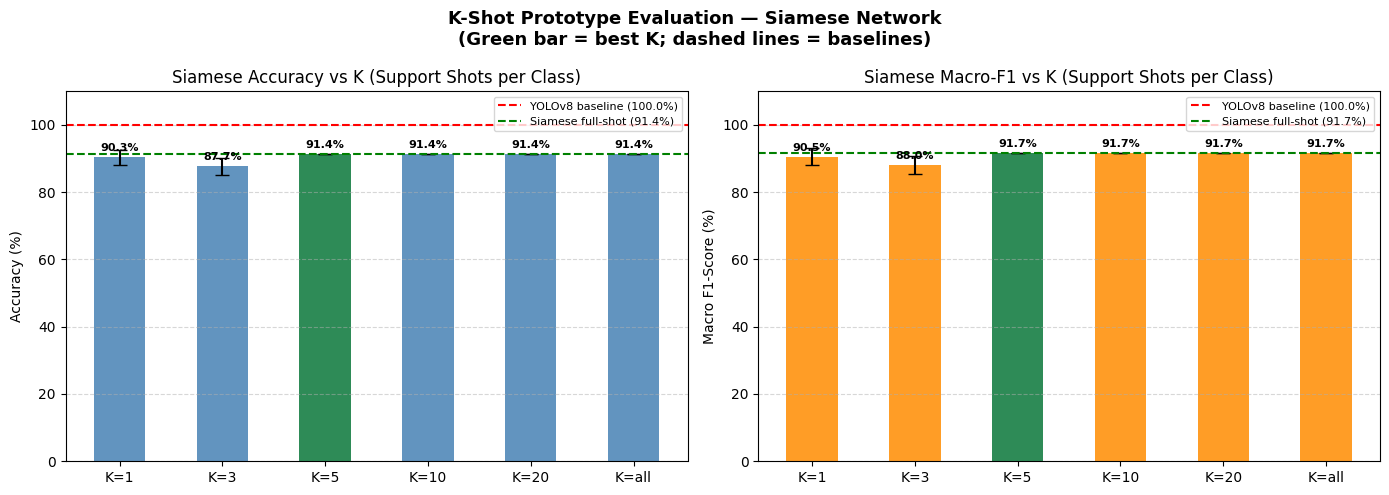

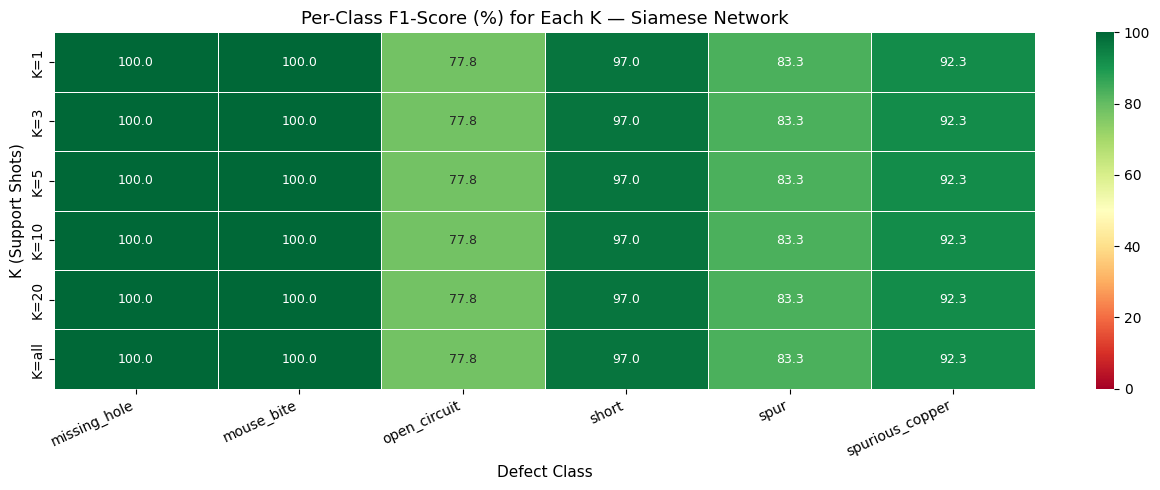


🏆 Best K by accuracy  : K=5  (91.43%)
🏆 Best K by macro-F1  : K=5  (91.73%)


In [ ]:
# ── K-Shot results plot ───────────────────────────────────────────────────────
labels   = K_LABELS
accs     = [kshot_results[l]['accuracy'] for l in labels]
f1s      = [kshot_results[l]['macro_f1'] for l in labels]
acc_stds = [kshot_results[l]['acc_std']  for l in labels]
f1_stds  = [kshot_results[l]['f1_std']   for l in labels]

x = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Accuracy ─────────────────────────────────────────────────────────
bars = axes[0].bar(x, accs, color='steelblue', alpha=0.85, width=0.5,
                   yerr=acc_stds, capsize=5, error_kw={'linewidth': 1.5})
axes[0].axhline(y=acc_yolo * 100, color='red',   linestyle='--', linewidth=1.5,
                label=f'YOLOv8 baseline ({acc_yolo*100:.1f}%)')
axes[0].axhline(y=acc_siam * 100, color='green', linestyle='--', linewidth=1.5,
                label=f'Siamese full-shot ({acc_siam*100:.1f}%)')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Siamese Accuracy vs K (Support Shots per Class)')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Mark best K
best_idx = accs.index(max(accs))
axes[0].get_children()[best_idx].set_facecolor('seagreen')
axes[0].get_children()[best_idx].set_alpha(1.0)

# ── Right: Macro-F1 ────────────────────────────────────────────────────────
bars2 = axes[1].bar(x, f1s, color='darkorange', alpha=0.85, width=0.5,
                    yerr=f1_stds, capsize=5, error_kw={'linewidth': 1.5})
ma_yolo_f1 = rdict_yolo.get('macro avg', {}).get('f1-score', 0) * 100
ma_siam_f1 = rdict_siam.get('macro avg', {}).get('f1-score', 0) * 100
axes[1].axhline(y=ma_yolo_f1, color='red',   linestyle='--', linewidth=1.5,
                label=f'YOLOv8 baseline ({ma_yolo_f1:.1f}%)')
axes[1].axhline(y=ma_siam_f1, color='green', linestyle='--', linewidth=1.5,
                label=f'Siamese full-shot ({ma_siam_f1:.1f}%)')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Macro F1-Score (%)')
axes[1].set_title('Siamese Macro-F1 vs K (Support Shots per Class)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for bar, f1 in zip(bars2, f1s):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
                 f'{f1:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Mark best K
best_f1_idx = f1s.index(max(f1s))
axes[1].get_children()[best_f1_idx].set_facecolor('seagreen')
axes[1].get_children()[best_f1_idx].set_alpha(1.0)

plt.suptitle('K-Shot Prototype Evaluation — Siamese Network\n'
             '(Green bar = best K; dashed lines = baselines)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Per-class F1 heatmap for each K ──────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 5))
heatmap_data = []
for label in labels:
    # Re-run a single pass (deterministic for K=all, one sample for others)
    k_val    = None if label == 'K=all' else int(label.split('=')[1])
    protos_k = build_prototypes(k=k_val, verbose=False)
    row = []
    yt2, yp2 = [], []
    for img_name in test_images:
        gt2 = get_gt_class(img_name, test_label_dir)
        if gt2 is None:
            continue
        img_path = os.path.join(test_img_dir, img_name)
        crop_t   = crop_image(img_path, _crop_detector)
        with torch.no_grad():
            emb2, logits2 = siamese_net.extract_with_logits(crop_t.unsqueeze(0).to(DEVICE))
        probs2           = torch.softmax(logits2, dim=1)
        ce_conf2, ce_cls2 = probs2.max(dim=1)
        pred2 = ce_cls2.item()
        if ce_conf2.item() < 0.4 and protos_k:
            qe = emb2.squeeze(0).cpu()
            bs2, bsim2 = -1, -float('inf')
            for ci2, pt2 in protos_k.items():
                s2 = torch.dot(qe, pt2).item()
                if s2 > bsim2:
                    bsim2, bs2 = s2, ci2
            pred2 = bs2
        yt2.append(gt2); yp2.append(pred2)
    rd2 = classification_report(yt2, yp2, labels=list(range(NUM_CLASSES)),
                                target_names=CLASSES, digits=4,
                                output_dict=True, zero_division=0)
    row = [rd2.get(c, {}).get('f1-score', 0) * 100 for c in CLASSES]
    heatmap_data.append(row)

hm_df = pd.DataFrame(heatmap_data, index=labels, columns=CLASSES)
sns.heatmap(hm_df, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=0.5, ax=ax2,
            annot_kws={'size': 9})
ax2.set_xlabel('Defect Class', fontsize=11)
ax2.set_ylabel('K (Support Shots)', fontsize=11)
ax2.set_title('Per-Class F1-Score (%) for Each K — Siamese Network', fontsize=13)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

print(f"\n🏆 Best K by accuracy  : {best_label}  ({best_res['accuracy']:.2f}%)")
best_f1_label = labels[best_f1_idx]
print(f"🏆 Best K by macro-F1  : {best_f1_label}  ({max(f1s):.2f}%)")


## 18. Few-Shot Learning Methods — DSRF / FSODM / TFA / VFA

Select the method to run by changing **`FSL_METHOD`** in the Config cell (Section 2).

| Variable | Effect |
|---|---|
| `FSL_METHOD = 'TFA'` | Two-stage Fine-tuning Approach |
| `FSL_METHOD = 'DSRF'` | Dense Semantic Relation Few-Shot |
| `FSL_METHOD = 'FSODM'` | Few-Shot with MAML-style meta-learning |
| `FSL_METHOD = 'VFA'` | Visual Feature Aggregation (multi-scale) |
| `FSL_METHOD = None` | Skip this section entirely |

`FSL_K` sets the number of support shots per class (default 5).  
`FSL_EPOCHS` sets fine-tuning / meta-training epochs (default 20).

---

### Method Descriptions

**TFA — Two-stage Fine-tuning Approach**  
The YOLOv8 backbone + EmbeddingHead are frozen. Only the `ClassificationHead` is fine-tuned
on a K-shot support set sampled from training data. This is the lightest-weight method and
often achieves the best accuracy-vs-compute trade-off.

**DSRF — Dense Semantic Relation Few-Shot**  
A `RelationNetwork` MLP takes the concatenated spatial feature maps (from backbone layer 9)
of a support crop and a query crop, and learns to output a similarity score.
Predictions use the highest-scoring support class. Inspired by *Learning to Compare*
(Sung et al., 2018).

**FSODM — Few-Shot with MAML-style Meta-learning**  
Episodic training: each episode samples N-way K-shot support + query sets. An *inner loop*
fast-adapts the `ClassificationHead` weights using a few gradient steps; the *outer loop*
updates the meta-parameters so the model adapts quickly from few examples (MAML, Finn 2017).

**VFA — Visual Feature Aggregation**  
Multi-scale features from backbone layers 6, 8 and 9 are average-pooled and concatenated,
then projected by a new `VFAHead` (replacing `EmbeddingHead` for this method only) to form
a richer 256-d embedding. Prototypes are built from K-shot support crops using VFA embeddings,
and nearest-prototype cosine search drives inference.


In [ ]:
"""
Section 18 — Few-Shot Method Definitions
=========================================
All four methods (TFA, DSRF, FSODM, VFA) are defined below.
Only the method selected by FSL_METHOD is actually executed —
the other three definitions are simply loaded into memory.
"""

import copy, itertools

# ─────────────────────────────────────────────────────────────────────────────
# Shared utility: collect K-shot support crops + labels from training set
# ─────────────────────────────────────────────────────────────────────────────

def _collect_kshot_support(k: int):
    """
    Sample k crops per class from the training split.
    Returns:
        support_crops  : Tensor  [N*k, 3, 224, 224]
        support_labels : Tensor  [N*k]   (int class indices)
    """
    crops, labels = [], []
    train_label_dir = os.path.join(output_dir, 'labels', 'train')
    train_img_dir   = os.path.join(output_dir, 'images', 'train')

    # Group training images by class
    class_files = {c: [] for c in range(NUM_CLASSES)}
    for img_name in os.listdir(train_img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        gt = get_gt_class(img_name, train_label_dir)
        if gt is not None:
            class_files[gt].append(img_name)

    rng = np.random.default_rng(seed=42)
    for cls_idx in range(NUM_CLASSES):
        files = class_files[cls_idx]
        if not files:
            continue
        chosen = rng.choice(files, size=min(k, len(files)), replace=False)
        for fname in chosen:
            img_path = os.path.join(train_img_dir, fname)
            crop_t   = crop_image(img_path, _crop_detector)   # [3,224,224]
            crops.append(crop_t)
            labels.append(cls_idx)

    return torch.stack(crops), torch.tensor(labels, dtype=torch.long)


# ─────────────────────────────────────────────────────────────────────────────
# 1.  TFA — Two-stage Fine-tuning Approach
# ─────────────────────────────────────────────────────────────────────────────

def run_TFA(k: int = 5, epochs: int = 20) -> list:
    """
    Freeze backbone + EmbeddingHead; fine-tune only ClassificationHead
    on a K-shot support set.  Returns test predictions (int list).
    """
    print(f"\n{'='*60}")
    print(f"  TFA  — Two-stage Fine-tuning Approach  (K={k}, epochs={epochs})")
    print(f"{'='*60}")

    # ── Clone the trained siamese net (do NOT modify the original) ────────────
    tfa_net = siamese_net.clone().to(DEVICE)

    # ── Freeze everything except the classification head ──────────────────────
    for name, param in tfa_net.named_parameters():
        if 'cls_head' not in name:
            param.requires_grad_(False)

    trainable = sum(p.numel() for p in tfa_net.parameters() if p.requires_grad)
    print(f"  Trainable parameters : {trainable:,}  (cls_head only)")

    # ── Build K-shot support loader ───────────────────────────────────────────
    support_crops, support_labels = _collect_kshot_support(k)

    class _SupportDS(torch.utils.data.Dataset):
        def __init__(self, crops, labels):
            self.crops, self.labels = crops, labels
        def __len__(self):  return len(self.labels)
        def __getitem__(self, i): return self.crops[i], self.labels[i]

    support_loader = torch.utils.data.DataLoader(
        _SupportDS(support_crops, support_labels),
        batch_size=min(32, len(support_labels)), shuffle=True,
    )

    optimiser = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, tfa_net.parameters()),
        lr=1e-3, weight_decay=1e-4,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)

    best_loss, best_state = float('inf'), None
    tfa_net.train()
    for ep in range(1, epochs + 1):
        ep_loss = 0.0
        for xb, yb in support_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            # extract_with_logits runs backbone + embed_head + cls_head in one pass
            _, logits = tfa_net.extract_with_logits(xb)
            loss = torch.nn.functional.cross_entropy(logits, yb)
            loss.backward()
            optimiser.step()
            ep_loss += loss.item()
        scheduler.step()
        avg = ep_loss / len(support_loader)
        if avg < best_loss:
            best_loss  = avg
            best_state = copy.deepcopy(tfa_net.state_dict())
        if ep % 5 == 0 or ep == 1:
            print(f"  epoch {ep:3d}/{epochs}  loss={avg:.4f}  lr={scheduler.get_last_lr()[0]:.2e}")

    tfa_net.load_state_dict(best_state)
    tfa_net.eval()
    print(f"  Fine-tuning done  (best loss={best_loss:.4f})")

    # ── Inference on test set ─────────────────────────────────────────────────
    # Build fresh prototypes from the TFA-adapted model for proto fallback
    tfa_protos = {}
    train_img_dir   = os.path.join(output_dir, 'images', 'train')
    train_label_dir = os.path.join(output_dir, 'labels', 'train')
    emb_acc = {c: [] for c in range(NUM_CLASSES)}
    for img_name in os.listdir(train_img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        gt = get_gt_class(img_name, train_label_dir)
        if gt is None:
            continue
        crop_t = crop_image(os.path.join(train_img_dir, img_name), _crop_detector)
        with torch.no_grad():
            emb, _ = tfa_net.extract_with_logits(crop_t.unsqueeze(0).to(DEVICE))
        emb_acc[gt].append(emb.squeeze(0).cpu())
    for c, embs in emb_acc.items():
        if embs:
            mean_e = torch.stack(embs).mean(0)
            tfa_protos[c] = torch.nn.functional.normalize(mean_e, p=2, dim=0)

    preds = []
    for img_name in test_images:
        gt = get_gt_class(img_name, test_label_dir)
        if gt is None:
            preds.append(-1)
            continue
        img_path = os.path.join(test_img_dir, img_name)
        crop_t   = crop_image(img_path, _crop_detector)
        with torch.no_grad():
            emb, logits = tfa_net.extract_with_logits(crop_t.unsqueeze(0).to(DEVICE))
        probs          = torch.softmax(logits, dim=1)
        ce_conf, ce_cls = probs.max(dim=1)
        pred = ce_cls.item()
        if ce_conf.item() < 0.4 and tfa_protos:
            qe = emb.squeeze(0).cpu()
            best_c, best_s = -1, -float('inf')
            for ci, pt in tfa_protos.items():
                s = torch.dot(qe, pt).item()
                if s > best_s:
                    best_s, best_c = s, ci
            pred = best_c
        preds.append(pred)

    return preds


# ─────────────────────────────────────────────────────────────────────────────
# 2.  DSRF — Dense Semantic Relation Few-Shot
# ─────────────────────────────────────────────────────────────────────────────

class _RelationNetwork(torch.nn.Module):
    """
    Relation network: takes concatenated spatial features of support and query,
    flattens and scores similarity via an MLP.
    Input: [B, 2*C, H, W]  →  scalar similarity per pair.
    """
    def __init__(self, in_channels: int = 512, feat_hw: int = 20):
        super().__init__()
        flat = in_channels * feat_hw * feat_hw
        self.net = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(flat, 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(256, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def run_DSRF(k: int = 5, epochs: int = 20) -> list:
    """
    Dense Semantic Relation Few-Shot (DSRF).
    Trains a relation network that scores (support_feat ⊕ query_feat) pairs.
    Returns test predictions (int list).
    """
    print(f"\n{'='*60}")
    print(f"  DSRF  — Dense Semantic Relation Few-Shot  (K={k}, epochs={epochs})")
    print(f"{'='*60}")

    # ── Extract spatial features from backbone layer 9 ────────────────────────
    dsrf_backbone = siamese_net.clone().to(DEVICE)
    dsrf_backbone.eval()
    for p in dsrf_backbone.parameters():
        p.requires_grad_(False)

    # Hook to capture spatial feature map (not pooled)
    _spatial_feat = {}

    def _spatial_hook(module, inp, out):
        _spatial_feat['map'] = out  # shape: [B, C, H, W]

    # Re-register hook for spatial output (before AdaptiveAvgPool in the existing hook)
    hook_layer = list(dsrf_backbone.backbone.model.model.children())[9]
    _sh = hook_layer.register_forward_hook(_spatial_hook)

    def _get_spatial(img_t: torch.Tensor) -> torch.Tensor:
        """Run backbone forward; return spatial map [1, C, H, W]."""
        with torch.no_grad():
            _ = dsrf_backbone.extract(img_t)
        return _spatial_feat['map'].cpu()

    sample_crop = crop_image(
        os.path.join(output_dir, 'images', 'train',
                     os.listdir(os.path.join(output_dir, 'images', 'train'))[0]),
        _crop_detector,
    )
    sample_feat = _get_spatial(sample_crop.unsqueeze(0).to(DEVICE))
    _, C_feat, H_feat, W_feat = sample_feat.shape
    print(f"  Spatial feature map: {C_feat}×{H_feat}×{W_feat}")

    # Resize spatial features to a fixed HxW to keep relation net input consistent
    FIXED_HW = min(H_feat, W_feat, 10)
    _pool_to_fixed = torch.nn.AdaptiveAvgPool2d((FIXED_HW, FIXED_HW))

    def _feat(img_t: torch.Tensor) -> torch.Tensor:
        raw = _get_spatial(img_t)                     # [1, C, H, W]
        return _pool_to_fixed(raw).squeeze(0)         # [C, FIXED_HW, FIXED_HW]

    # ── Build support feature set ─────────────────────────────────────────────
    support_crops, support_labels = _collect_kshot_support(k)
    support_feats = []
    for i in range(len(support_crops)):
        support_feats.append(_feat(support_crops[i].unsqueeze(0).to(DEVICE)))
    # support_feats: list of [C, FH, FW]  length = NUM_CLASSES * k

    # ── Train relation network ────────────────────────────────────────────────
    rel_net = _RelationNetwork(in_channels=C_feat, feat_hw=FIXED_HW).to(DEVICE)
    opt_rel = torch.optim.Adam(rel_net.parameters(), lr=1e-3)
    sch_rel = torch.optim.lr_scheduler.CosineAnnealingLR(opt_rel, T_max=epochs)

    # Build all (support, query, label) training pairs from support set itself
    # (we re-use support crops as queries — small but effective for K-shot)
    rel_X, rel_y = [], []
    for qi, (qf, ql) in enumerate(zip(support_feats, support_labels.tolist())):
        for si, (sf, sl) in enumerate(zip(support_feats, support_labels.tolist())):
            if qi == si:
                continue
            pair = torch.cat([sf, qf], dim=0).unsqueeze(0)  # [1, 2C, FH, FW]
            rel_X.append(pair)
            rel_y.append(1.0 if ql == sl else 0.0)

    rel_X = torch.cat(rel_X, dim=0)
    rel_y = torch.tensor(rel_y, dtype=torch.float32)

    class _RelDS(torch.utils.data.Dataset):
        def __init__(self, X, y): self.X, self.y = X, y
        def __len__(self): return len(self.y)
        def __getitem__(self, i): return self.X[i], self.y[i]

    rel_loader = torch.utils.data.DataLoader(
        _RelDS(rel_X, rel_y), batch_size=64, shuffle=True,
    )

    bce = torch.nn.BCELoss()
    rel_net.train()
    for ep in range(1, epochs + 1):
        ep_loss = 0.0
        for xb, yb in rel_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt_rel.zero_grad()
            scores = rel_net(xb)
            loss   = bce(scores, yb)
            loss.backward()
            opt_rel.step()
            ep_loss += loss.item()
        sch_rel.step()
        if ep % 5 == 0 or ep == 1:
            print(f"  epoch {ep:3d}/{epochs}  loss={ep_loss/len(rel_loader):.4f}")

    rel_net.eval()
    _sh.remove()

    # ── Inference: score query vs each support class prototype (mean feat) ────
    # Build per-class mean support feature
    class_mean_feats = {}
    for cls_idx in range(NUM_CLASSES):
        mask   = (support_labels == cls_idx)
        fs     = [support_feats[i] for i in range(len(support_feats)) if mask[i]]
        if fs:
            class_mean_feats[cls_idx] = torch.stack(fs).mean(0)  # [C, FH, FW]

    # Re-register hook for inference
    _sh2 = hook_layer.register_forward_hook(_spatial_hook)

    preds = []
    for img_name in test_images:
        gt = get_gt_class(img_name, test_label_dir)
        if gt is None:
            preds.append(-1)
            continue
        img_path = os.path.join(test_img_dir, img_name)
        crop_t   = crop_image(img_path, _crop_detector)
        qf       = _feat(crop_t.unsqueeze(0).to(DEVICE))   # [C, FH, FW]

        best_c, best_s = -1, -float('inf')
        for cls_idx, sf_mean in class_mean_feats.items():
            pair = torch.cat([sf_mean, qf], dim=0).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                score = rel_net(pair).item()
            if score > best_s:
                best_s, best_c = score, cls_idx
        preds.append(best_c)

    _sh2.remove()
    return preds


# ─────────────────────────────────────────────────────────────────────────────
# 3.  FSODM — Few-Shot with MAML-style meta-learning
# ─────────────────────────────────────────────────────────────────────────────

def run_FSODM(k: int = 5, meta_epochs: int = 20,
              n_way: int = 6, inner_steps: int = 5,
              inner_lr: float = 1e-2) -> list:

    print(f"\n{'='*60}")
    print(f"  FSODM — MAML-style meta-learning  (K={k}, meta-epochs={meta_epochs})")
    print(f"  n_way={n_way}, inner_steps={inner_steps}, inner_lr={inner_lr:.2e}")
    print(f"{'='*60}")

    n_way = min(n_way, NUM_CLASSES)

    # ── Collect training crops ───────────────────────────────────────────────
    train_img_dir   = os.path.join(output_dir, 'images', 'train')
    train_label_dir = os.path.join(output_dir, 'labels', 'train')

    all_crops = {c: [] for c in range(NUM_CLASSES)}
    for img_name in os.listdir(train_img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        gt = get_gt_class(img_name, train_label_dir)
        if gt is None:
            continue

        crop_t = crop_image(os.path.join(train_img_dir, img_name), _crop_detector)
        all_crops[gt].append(crop_t)

    eligible = [c for c in range(NUM_CLASSES) if len(all_crops[c]) >= 2 * k]
    if len(eligible) < n_way:
        n_way = len(eligible)
        print(f"  ⚠ Reduced n_way to {n_way} (limited data)")

    # ── Meta model ───────────────────────────────────────────────────────────
    meta_net = siamese_net.clone().to(DEVICE)

    for name, p in meta_net.named_parameters():
        p.requires_grad_(('cls_head' in name))

    meta_opt = torch.optim.Adam(
        filter(lambda p: p.requires_grad, meta_net.parameters()),
        lr=1e-3
    )

    rng = np.random.default_rng(seed=0)

    # ────────────────────────────────────────────────────────────────────────
    # Episode sampler
    # ────────────────────────────────────────────────────────────────────────
    def _episode():
        classes = rng.choice(eligible, size=n_way, replace=False).tolist()

        sup_x, sup_y, qry_x, qry_y = [], [], [], []

        for local_label, cls_idx in enumerate(classes):
            imgs = all_crops[cls_idx]

            chosen = rng.choice(len(imgs), size=min(2 * k, len(imgs)), replace=False)
            sup_idx = chosen[:k]
            qry_idx = chosen[k:] if len(chosen) > k else chosen[:1]

            for i in sup_idx:
                sup_x.append(imgs[i])
                sup_y.append(local_label)

            for i in qry_idx:
                qry_x.append(imgs[i])
                qry_y.append(local_label)

        return (
            torch.stack(sup_x).to(DEVICE),
            torch.tensor(sup_y, dtype=torch.long).to(DEVICE),
            torch.stack(qry_x).to(DEVICE),
            torch.tensor(qry_y, dtype=torch.long).to(DEVICE),
        )

    episodes_per_epoch = max(10, len(eligible))
    print(f"  Episodes per epoch : {episodes_per_epoch}")

    meta_net.train()

    # ────────────────────────────────────────────────────────────────────────
    # Training loop
    # ────────────────────────────────────────────────────────────────────────
    for ep in range(1, meta_epochs + 1):

        ep_loss = 0.0

        for _ in range(episodes_per_epoch):

            sup_x, sup_y, qry_x, qry_y = _episode()

            emb_sup = meta_net.extract(sup_x)
            emb_qry = meta_net.extract(qry_x)

            # ── clone ALL classifier params safely ─────────────────────────
            fast_weights = {
                name: param.clone()
                for name, param in meta_net.cls_head.named_parameters()
            }

            # ── inner loop ─────────────────────────────────────────────────
            for _ in range(inner_steps):

                # extract weight/bias dynamically
                weight = None
                bias = None

                for k, v in fast_weights.items():
                    if "weight" in k:
                        weight = v
                    if "bias" in k:
                        bias = v

                logits_sup = torch.nn.functional.linear(
                    emb_sup,
                    weight,
                    bias
                )

                loss = torch.nn.functional.cross_entropy(logits_sup, sup_y)

                grads = torch.autograd.grad(
                    loss,
                    list(fast_weights.values()),
                    create_graph=True,
                    allow_unused=True
                )

                grads = list(grads)
                w_grad = grads[0] if len(grads) > 0 else None
                b_grad = grads[1] if len(grads) > 1 else None

                # update fast weights
                for i, (name, param) in enumerate(fast_weights.items()):
                    if "weight" in name and w_grad is not None:
                        fast_weights[name] = param - inner_lr * w_grad
                    if "bias" in name and b_grad is not None:
                        fast_weights[name] = param - inner_lr * b_grad

            # ── outer loop ─────────────────────────────────────────────────
            weight = None
            bias = None

            for k, v in fast_weights.items():
                if "weight" in k:
                    weight = v
                if "bias" in k:
                    bias = v

            logits_qry = torch.nn.functional.linear(
                emb_qry,
                weight,
                bias
            )

            outer_loss = torch.nn.functional.cross_entropy(logits_qry, qry_y)

            meta_opt.zero_grad()
            outer_loss.backward()
            torch.nn.utils.clip_grad_norm_(meta_net.parameters(), 1.0)
            meta_opt.step()

            ep_loss += outer_loss.item()

        if ep % 5 == 0 or ep == 1:
            print(f"  epoch {ep:3d}/{meta_epochs}  avg_outer_loss={ep_loss/episodes_per_epoch:.4f}")

    # ────────────────────────────────────────────────────────────────────────
    # Inference
    # ────────────────────────────────────────────────────────────────────────
    meta_net.eval()

    preds = []

    for img_name in test_images:

        gt = get_gt_class(img_name, test_label_dir)
        if gt is None:
            preds.append(-1)
            continue

        img_path = os.path.join(test_img_dir, img_name)
        crop_t = crop_image(img_path, _crop_detector)

        with torch.no_grad():
            emb = meta_net.extract(crop_t.unsqueeze(0).to(DEVICE))

        logits = meta_net.cls_head(emb)
        pred = torch.argmax(logits, dim=1).item()

        preds.append(pred)

    return preds


# ─────────────────────────────────────────────────────────────────────────────
# 4.  VFA — Visual Feature Aggregation (multi-scale)
# ─────────────────────────────────────────────────────────────────────────────

class _VFAHead(torch.nn.Module):
    """
    Multi-scale feature head.
    Takes concatenated average-pooled features from layers 6, 8, and 9,
    projects to EMBED_DIM, L2-normalises.
    """
    def __init__(self, in_dims: list, embed_dim: int = 256):
        super().__init__()
        total = sum(in_dims)
        self.proj = torch.nn.Sequential(
            torch.nn.Linear(total, embed_dim * 2),
            torch.nn.BatchNorm1d(embed_dim * 2),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(embed_dim * 2, embed_dim),
            torch.nn.BatchNorm1d(embed_dim),
        )
        self.embed_dim = embed_dim

    def forward(self, feat_list: list) -> torch.Tensor:
        """feat_list: list of [B, C, H, W] tensors from different layers."""
        pooled = [torch.nn.functional.adaptive_avg_pool2d(f, 1).flatten(1)
                  for f in feat_list]
        cat    = torch.cat(pooled, dim=1)
        emb    = self.proj(cat)
        return torch.nn.functional.normalize(emb, p=2, dim=1)


def run_VFA(k: int = 5, epochs: int = 20) -> list:
    """
    Visual Feature Aggregation (VFA).
    Multi-scale features from backbone layers 6, 8, 9 are aggregated
    by a new VFAHead, trained on K-shot support with CE loss.
    Returns test predictions (int list).
    """
    print(f"\n{'='*60}")
    print(f"  VFA  — Visual Feature Aggregation  (K={k}, epochs={epochs})")
    print(f"{'='*60}")

    # ── Frozen backbone from trained siamese ──────────────────────────────────
    vfa_backbone = siamese_net.clone().to(DEVICE)
    for p in vfa_backbone.parameters():
        p.requires_grad_(False)
    vfa_backbone.eval()

    # ── Multi-scale hooks on layers 6, 8, 9 ──────────────────────────────────
    _ms_feats: dict = {}
    _backbone_children = list(vfa_backbone.backbone.model.model.children())

    def _make_hook(tag):
        def _h(module, inp, out):
            _ms_feats[tag] = out
        return _h

    _hooks = [
        _backbone_children[6].register_forward_hook(_make_hook('l6')),
        _backbone_children[8].register_forward_hook(_make_hook('l8')),
        _backbone_children[9].register_forward_hook(_make_hook('l9')),
    ]

    # ── Determine channel dims from one forward pass ──────────────────────────
    sample_crop = crop_image(
        os.path.join(output_dir, 'images', 'train',
                     os.listdir(os.path.join(output_dir, 'images', 'train'))[0]),
        _crop_detector,
    )
    with torch.no_grad():
        _ = vfa_backbone.extract(sample_crop.unsqueeze(0).to(DEVICE))

    dims = []
    for tag in ('l6', 'l8', 'l9'):
        f = _ms_feats.get(tag)
        if f is None:
            raise RuntimeError(f"VFA hook for {tag} did not fire — check backbone layer indexing")
        dims.append(f.shape[1])
    print(f"  Multi-scale channel dims : {dims}  (layers 6, 8, 9)")

    # ── VFAHead + classifier ──────────────────────────────────────────────────
    vfa_head = _VFAHead(in_dims=dims, embed_dim=EMBED_DIM).to(DEVICE)
    vfa_cls  = torch.nn.Linear(EMBED_DIM, NUM_CLASSES).to(DEVICE)

    params_vfa = list(vfa_head.parameters()) + list(vfa_cls.parameters())
    opt_vfa = torch.optim.AdamW(params_vfa, lr=1e-3, weight_decay=1e-4)
    sch_vfa = torch.optim.lr_scheduler.CosineAnnealingLR(opt_vfa, T_max=epochs)

    def _vfa_forward(crops: torch.Tensor):
        """crops: [B, 3, H, W]  → embedding [B, EMBED_DIM], logits [B, NUM_CLASSES]"""
        with torch.no_grad():
            _ = vfa_backbone.extract(crops)
        feat_list = [_ms_feats.get(t, torch.zeros(crops.shape[0], 1, 1, 1).to(DEVICE))
                     for t in ('l6', 'l8', 'l9')]
        logits = vfa_cls(emb)
        return emb, logits

    # ── Build K-shot support loader ───────────────────────────────────────────
    support_crops, support_labels = _collect_kshot_support(k)

    class _SDS(torch.utils.data.Dataset):
        def __init__(self, c, l): self.c, self.l = c, l
        def __len__(self): return len(self.l)
        def __getitem__(self, i): return self.c[i], self.l[i]

    sup_loader = torch.utils.data.DataLoader(
        _SDS(support_crops, support_labels),
        batch_size=min(32, len(support_labels)), shuffle=True,
    )

    # ── Train VFAHead + classifier ────────────────────────────────────────────
    vfa_head.train(); vfa_cls.train()
    best_loss, best_state_vfa = float('inf'), None
    for ep in range(1, epochs + 1):
        ep_loss = 0.0
        for xb, yb in sup_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt_vfa.zero_grad()
            _, logits = _vfa_forward(xb)
            loss = torch.nn.functional.cross_entropy(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params_vfa, 1.0)
            opt_vfa.step()
            ep_loss += loss.item()
        sch_vfa.step()
        avg = ep_loss / len(sup_loader)
        if avg < best_loss:
            best_loss = avg
            best_state_vfa = (copy.deepcopy(vfa_head.state_dict()),
                              copy.deepcopy(vfa_cls.state_dict()))
        if ep % 5 == 0 or ep == 1:
            print(f"  epoch {ep:3d}/{epochs}  loss={avg:.4f}")

    vfa_head.load_state_dict(best_state_vfa[0])
    vfa_cls.load_state_dict(best_state_vfa[1])
    vfa_head.eval(); vfa_cls.eval()
    print(f"  VFA training done  (best loss={best_loss:.4f})")

    # ── Build VFA prototypes from full training set ───────────────────────────
    train_img_dir   = os.path.join(output_dir, 'images', 'train')
    train_label_dir = os.path.join(output_dir, 'labels', 'train')
    vfa_protos_acc  = {c: [] for c in range(NUM_CLASSES)}
    for img_name in os.listdir(train_img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        gt = get_gt_class(img_name, train_label_dir)
        if gt is None:
            continue
        crop_t = crop_image(os.path.join(train_img_dir, img_name), _crop_detector)
        with torch.no_grad():
            emb_v, _ = _vfa_forward(crop_t.unsqueeze(0).to(DEVICE))
        vfa_protos_acc[gt].append(emb_v.squeeze(0).cpu())
    vfa_protos = {}
    for c, embs in vfa_protos_acc.items():
        if embs:
            mean_e = torch.stack(embs).mean(0)
            vfa_protos[c] = torch.nn.functional.normalize(mean_e, p=2, dim=0)

    # ── Inference ─────────────────────────────────────────────────────────────
    preds = []
    for img_name in test_images:
        gt = get_gt_class(img_name, test_label_dir)
        if gt is None:
            preds.append(-1)
            continue
        img_path = os.path.join(test_img_dir, img_name)
        crop_t   = crop_image(img_path, _crop_detector)
        with torch.no_grad():
            emb_v, logits_v = _vfa_forward(crop_t.unsqueeze(0).to(DEVICE))
        probs_v = torch.softmax(logits_v, dim=1)
        ce_v, cc_v = probs_v.max(dim=1)
        pred = cc_v.item()
        if ce_v.item() < 0.4 and vfa_protos:
            qe = emb_v.squeeze(0).cpu()
            best_c, best_s = -1, -float('inf')
            for ci, pt in vfa_protos.items():
                s = torch.dot(qe, pt).item()
                if s > best_s:
                    best_s, best_c = s, ci
            pred = best_c
        preds.append(pred)

    # Remove hooks
    for h in _hooks:
        h.remove()

    return preds


# ─────────────────────────────────────────────────────────────────────────────
# Dispatcher
# ─────────────────────────────────────────────────────────────────────────────

def dispatch_fsl(method: str, k: int, epochs: int) -> list:
    """Run the selected few-shot method and return its test predictions."""
    method = method.upper()
    if method == 'TFA':
        return run_TFA(k=k, epochs=epochs)
    elif method == 'DSRF':
        return run_DSRF(k=k, epochs=epochs)
    elif method == 'FSODM':
        return run_FSODM(k=k, meta_epochs=epochs)
    elif method == 'VFA':
        return run_VFA(k=k, epochs=epochs)
    else:
        raise ValueError(f"Unknown FSL_METHOD='{method}'. "
                         f"Choose from: 'TFA', 'DSRF', 'FSODM', 'VFA'.")

print("✅  Few-shot method definitions loaded: TFA | DSRF | FSODM | VFA")
print(f"   Selected method : FSL_METHOD = '{FSL_METHOD}'")
print(f"   Support shots   : FSL_K      = {FSL_K}")
print(f"   Training epochs : FSL_EPOCHS = {FSL_EPOCHS}")


✅  Few-shot method definitions loaded: TFA | DSRF | FSODM | VFA
   Selected method : FSL_METHOD = 'FSODM'
   Support shots   : FSL_K      = 5
   Training epochs : FSL_EPOCHS = 10


In [ ]:
def run_FSODM(k: int = 5, meta_epochs: int = 20,
              n_way: int = 6, inner_steps: int = 5,
              inner_lr: float = 1e-2) -> list:

    print(f"\n{'='*60}")
    print(f"  FSODM — MAML-style meta-learning  (K={k}, meta-epochs={meta_epochs})")
    print(f"  n_way={n_way}, inner_steps={inner_steps}, inner_lr={inner_lr:.2e}")
    print(f"{'='*60}")

    # ── SAFE TYPE CONVERSION ─────────────────────────────
    k = int(float(k))
    meta_epochs = int(meta_epochs)
    n_way = min(n_way, NUM_CLASSES)

    train_img_dir   = os.path.join(output_dir, 'images', 'train')
    train_label_dir = os.path.join(output_dir, 'labels', 'train')

    # ── BUILD CLASS DATASET ──────────────────────────────
    all_crops = {c: [] for c in range(NUM_CLASSES)}

    for img_name in os.listdir(train_img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        gt = get_gt_class(img_name, train_label_dir)
        if gt is None:
            continue

        crop_t = crop_image(os.path.join(train_img_dir, img_name), _crop_detector)
        all_crops[gt].append(crop_t)

    eligible = [c for c in range(NUM_CLASSES) if len(all_crops[c]) >= 2 * k]

    if len(eligible) < n_way:
        n_way = len(eligible)
        print(f"  ⚠ Reduced n_way to {n_way}")

    meta_net = siamese_net.clone().to(DEVICE)

    # only train classifier head
    for name, p in meta_net.named_parameters():
        p.requires_grad_(('cls_head' in name))

    meta_opt = torch.optim.Adam(
        filter(lambda p: p.requires_grad, meta_net.parameters()),
        lr=1e-3
    )

    rng = np.random.default_rng(seed=0)

    # ─────────────────────────────────────────────
    # SAFE EPISODE SAMPLER
    # ─────────────────────────────────────────────
    def _episode():

        classes = rng.choice(eligible, size=n_way, replace=False).tolist()

        sup_x, sup_y, qry_x, qry_y = [], [], [], []

        for local_label, cls_idx in enumerate(classes):

            imgs = all_crops[cls_idx]
            if len(imgs) < 2:
                continue

            num_samples = min(2 * k, len(imgs))
            chosen = rng.choice(len(imgs), size=num_samples, replace=False)

            sup_idx = chosen[:k]
            qry_idx = chosen[k:] if len(chosen) > k else chosen[:1]

            for i in sup_idx:
                sup_x.append(imgs[i])
                sup_y.append(local_label)

            for i in qry_idx:
                qry_x.append(imgs[i])
                qry_y.append(local_label)

        if len(sup_x) == 0 or len(qry_x) == 0:
            return _episode()

        return (
            torch.stack(sup_x).to(DEVICE),
            torch.tensor(sup_y, dtype=torch.long).to(DEVICE),
            torch.stack(qry_x).to(DEVICE),
            torch.tensor(qry_y, dtype=torch.long).to(DEVICE),
        )

    episodes_per_epoch = max(10, len(eligible))
    print(f"  Episodes per epoch : {episodes_per_epoch}")

    meta_net.train()

    # ─────────────────────────────────────────────
    # META TRAINING LOOP
    # ─────────────────────────────────────────────
    for ep in range(1, meta_epochs + 1):

        ep_loss = 0.0

        for _ in range(episodes_per_epoch):

            sup_x, sup_y, qry_x, qry_y = _episode()

            emb_sup = meta_net.extract(sup_x)
            emb_qry = meta_net.extract(qry_x)

            # ── FAST WEIGHTS (FIXED) ─────────────────────────────
            fast_weights = {
                name: param.clone().detach().requires_grad_(True)
                for name, param in meta_net.cls_head.named_parameters()
            }

            weight_key = [k for k in fast_weights if "weight" in k][0]
            bias_key   = [k for k in fast_weights if "bias" in k][0]

            # ── INNER LOOP ───────────────────────────────────────
            for _ in range(inner_steps):

                weight = fast_weights[weight_key]
                bias   = fast_weights[bias_key]

                logits_sup = torch.nn.functional.linear(emb_sup, weight, bias)
                loss = torch.nn.functional.cross_entropy(logits_sup, sup_y)

                grads = torch.autograd.grad(
                    loss,
                    [fast_weights[weight_key], fast_weights[bias_key]],
                    create_graph=True
                )

                fast_weights[weight_key] = fast_weights[weight_key] - inner_lr * grads[0]
                fast_weights[bias_key]   = fast_weights[bias_key]   - inner_lr * grads[1]

            # ── OUTER LOSS ───────────────────────────────────────
            logits_qry = torch.nn.functional.linear(
                emb_qry,
                fast_weights[weight_key],
                fast_weights[bias_key]
            )

            outer_loss = torch.nn.functional.cross_entropy(logits_qry, qry_y)

            meta_opt.zero_grad()
            outer_loss.backward()
            torch.nn.utils.clip_grad_norm_(meta_net.parameters(), 1.0)
            meta_opt.step()

            ep_loss += outer_loss.item()

        if ep % 5 == 0 or ep == 1:
            print(f"  epoch {ep:3d}/{meta_epochs}  loss={ep_loss/episodes_per_epoch:.4f}")

    # ─────────────────────────────────────────────
    # INFERENCE
    # ─────────────────────────────────────────────
    meta_net.eval()
    preds = []

    test_label_dir = os.path.join(output_dir, 'labels', 'test')

    for img_name in test_images:

        gt = get_gt_class(img_name, test_label_dir)
        if gt is None:
            preds.append(-1)
            continue

        img_path = os.path.join(test_img_dir, img_name)
        crop_t = crop_image(img_path, _crop_detector)

        with torch.no_grad():
            emb = meta_net.extract(crop_t.unsqueeze(0).to(DEVICE))

        logits = meta_net.cls_head(emb)
        preds.append(torch.argmax(logits, dim=1).item())

    return preds

Running few-shot method: FSODM  (K=5, epochs=10)

  FSODM — MAML-style meta-learning  (K=5, meta-epochs=10)
  n_way=6, inner_steps=5, inner_lr=1.00e-02
  Episodes per epoch : 10
  epoch   1/10  loss=1.9915
  epoch   5/10  loss=1.9065
  epoch  10/10  loss=1.8638

──────────────────────────────────────────────────────────
  FSODM Results  (K=5 support shots per class)
──────────────────────────────────────────────────────────
  Accuracy  : 91.43%
  Macro P   : 0.9524
  Macro R   : 0.9058
  Macro F1  : 0.9173
──────────────────────────────────────────────────────────
                 precision    recall  f1-score   support

   missing_hole     1.0000    1.0000    1.0000        11
     mouse_bite     1.0000    1.0000    1.0000         9
   open_circuit     1.0000    0.6364    0.7778        11
          short     1.0000    0.9412    0.9697        17
           spur     0.7143    1.0000    0.8333        15
spurious_copper     1.0000    0.8571    0.9231         7

       accuracy             

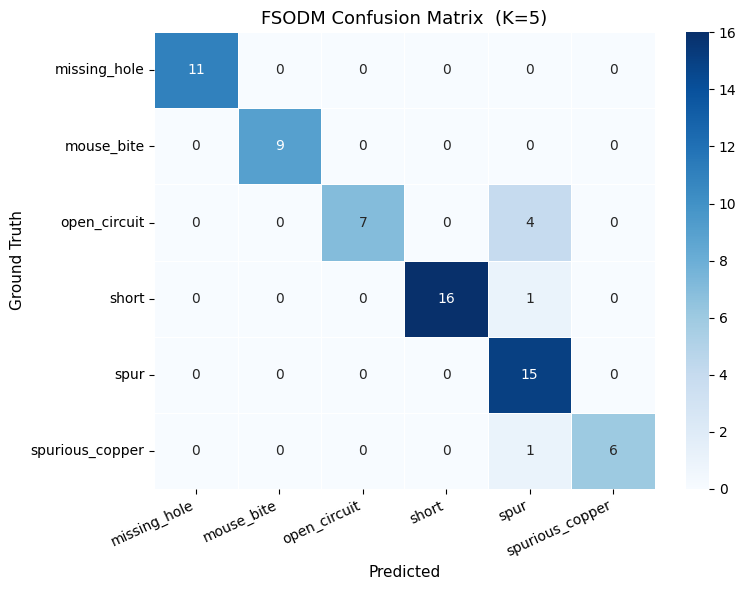

In [ ]:
# ── Run the selected few-shot method ─────────────────────────────────────────
#    Change FSL_METHOD in the Config cell (Section 2) to switch methods.
#    Set FSL_METHOD = None to skip this section entirely.

if FSL_METHOD is None:
    print("FSL_METHOD = None  →  Skipping few-shot evaluation.")
    fsl_preds = None
else:
    print(f"Running few-shot method: {FSL_METHOD}  (K={FSL_K}, epochs={FSL_EPOCHS})")
    fsl_preds = dispatch_fsl(FSL_METHOD, FSL_K, FSL_EPOCHS)

    # ── Collect ground-truth for the same test images used above ──────────────
    fsl_gt = []
    fsl_yp = []
    for img_name, pred in zip(test_images, fsl_preds):
        gt = get_gt_class(img_name, test_label_dir)
        if gt is None or pred == -1:
            continue
        fsl_gt.append(gt)
        fsl_yp.append(pred)

    # ── Accuracy & classification report ─────────────────────────────────────
    acc_fsl   = accuracy_score(fsl_gt, fsl_yp)
    rdict_fsl = classification_report(
        fsl_gt, fsl_yp,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASSES,
        digits=4,
        output_dict=True,
        zero_division=0,
    )
    ma_fsl = rdict_fsl.get('macro avg', {})

    print(f"\n{'─'*58}")
    print(f"  {FSL_METHOD} Results  (K={FSL_K} support shots per class)")
    print(f"{'─'*58}")
    print(f"  Accuracy  : {acc_fsl*100:.2f}%")
    print(f"  Macro P   : {ma_fsl.get('precision',0):.4f}")
    print(f"  Macro R   : {ma_fsl.get('recall',0):.4f}")
    print(f"  Macro F1  : {ma_fsl.get('f1-score',0):.4f}")
    print(f"{'─'*58}")
    print(classification_report(
        fsl_gt, fsl_yp,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASSES,
        digits=4,
        zero_division=0,
    ))

    # ── Confusion matrix ──────────────────────────────────────────────────────
    fig_fsl, ax_fsl = plt.subplots(figsize=(8, 6))
    cm_fsl = confusion_matrix(fsl_gt, fsl_yp, labels=list(range(NUM_CLASSES)))
    sns.heatmap(
        pd.DataFrame(cm_fsl, index=CLASSES, columns=CLASSES),
        annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax_fsl,
    )
    ax_fsl.set_xlabel('Predicted', fontsize=11)
    ax_fsl.set_ylabel('Ground Truth', fontsize=11)
    ax_fsl.set_title(f'{FSL_METHOD} Confusion Matrix  (K={FSL_K})', fontsize=13)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()


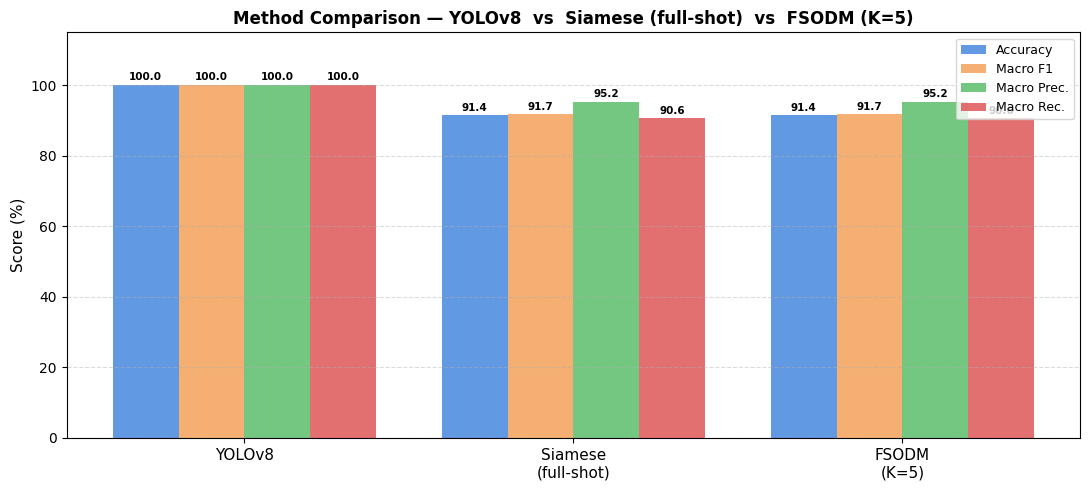

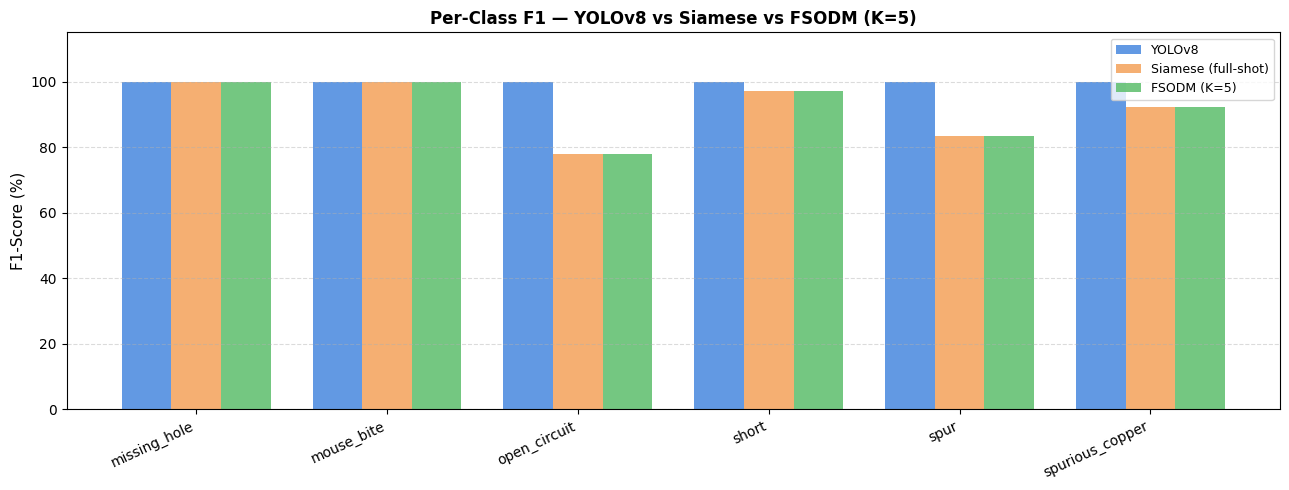


╔══════════════════════════════════════════════════════════════╗
║    Few-Shot Method Comparison Summary                        ║
╠══════════════════════════════════════════════════════════════╣
║  Method                      Acc   Macro-P   Macro-R  Macro-F1 ║
╠══════════════════════════════════════════════════════════════╣
║  YOLOv8 (detection)      100.00%    1.0000    1.0000    1.0000 ║
║  Siamese (full-shot)      91.43%    0.9524    0.9058    0.9173 ║
║  FSODM (K=5)              91.43%    0.9524    0.9058    0.9173 ║
╚══════════════════════════════════════════════════════════════╝


In [ ]:
# ── Few-shot vs baseline comparison plots ─────────────────────────────────────
if FSL_METHOD is None or fsl_preds is None:
    print("FSL_METHOD = None  →  No comparison plot.")
else:
    # ── Gather metrics ────────────────────────────────────────────────────────
    ma_yolo_f = rdict_yolo.get('macro avg', {})
    ma_siam_f = rdict_siam.get('macro avg', {})

    methods   = ['YOLOv8', 'Siamese\n(full-shot)', f'{FSL_METHOD}\n(K={FSL_K})']
    accs_cmp  = [acc_yolo * 100, acc_siam * 100, acc_fsl * 100]
    f1s_cmp   = [ma_yolo_f.get('f1-score', 0) * 100,
                 ma_siam_f.get('f1-score', 0) * 100,
                 ma_fsl.get('f1-score', 0) * 100]
    prec_cmp  = [ma_yolo_f.get('precision', 0) * 100,
                 ma_siam_f.get('precision', 0) * 100,
                 ma_fsl.get('precision', 0) * 100]
    rec_cmp   = [ma_yolo_f.get('recall', 0) * 100,
                 ma_siam_f.get('recall', 0) * 100,
                 ma_fsl.get('recall', 0) * 100]

    x       = np.arange(len(methods))
    bar_w   = 0.20
    palette = ['#4C8BE0', '#F4A45E', '#61C070', '#E05C5C']   # acc, f1, prec, rec

    fig_cmp, ax_cmp = plt.subplots(figsize=(11, 5))

    b1 = ax_cmp.bar(x - 1.5 * bar_w, accs_cmp,  bar_w, label='Accuracy',    color=palette[0], alpha=0.88)
    b2 = ax_cmp.bar(x - 0.5 * bar_w, f1s_cmp,   bar_w, label='Macro F1',    color=palette[1], alpha=0.88)
    b3 = ax_cmp.bar(x + 0.5 * bar_w, prec_cmp,  bar_w, label='Macro Prec.', color=palette[2], alpha=0.88)
    b4 = ax_cmp.bar(x + 1.5 * bar_w, rec_cmp,   bar_w, label='Macro Rec.',  color=palette[3], alpha=0.88)

    # Value labels
    for bars in (b1, b2, b3, b4):
        for bar in bars:
            ax_cmp.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{bar.get_height():.1f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold',
            )

    ax_cmp.set_xticks(x)
    ax_cmp.set_xticklabels(methods, fontsize=11)
    ax_cmp.set_ylim(0, 115)
    ax_cmp.set_ylabel('Score (%)', fontsize=11)
    ax_cmp.set_title(
        f'Method Comparison — YOLOv8  vs  Siamese (full-shot)  vs  {FSL_METHOD} (K={FSL_K})',
        fontsize=12, fontweight='bold',
    )
    ax_cmp.legend(fontsize=9, loc='upper right')
    ax_cmp.grid(axis='y', linestyle='--', alpha=0.45)
    plt.tight_layout()
    plt.show()

    # ── Per-class F1 grouped bar chart ────────────────────────────────────────
    yolo_f1s = [rdict_yolo.get(c, {}).get('f1-score', 0) * 100 for c in CLASSES]
    siam_f1s = [rdict_siam.get(c, {}).get('f1-score', 0) * 100 for c in CLASSES]
    fsl_f1s  = [rdict_fsl.get(c,  {}).get('f1-score', 0) * 100 for c in CLASSES]

    x2    = np.arange(NUM_CLASSES)
    bw2   = 0.26

    fig2_cmp, ax2_cmp = plt.subplots(figsize=(13, 5))
    ax2_cmp.bar(x2 - bw2, yolo_f1s, bw2, label='YOLOv8',             color='#4C8BE0', alpha=0.88)
    ax2_cmp.bar(x2,        siam_f1s, bw2, label='Siamese (full-shot)', color='#F4A45E', alpha=0.88)
    ax2_cmp.bar(x2 + bw2,  fsl_f1s,  bw2, label=f'{FSL_METHOD} (K={FSL_K})', color='#61C070', alpha=0.88)

    ax2_cmp.set_xticks(x2)
    ax2_cmp.set_xticklabels(CLASSES, rotation=25, ha='right', fontsize=10)
    ax2_cmp.set_ylim(0, 115)
    ax2_cmp.set_ylabel('F1-Score (%)', fontsize=11)
    ax2_cmp.set_title(
        f'Per-Class F1 — YOLOv8 vs Siamese vs {FSL_METHOD} (K={FSL_K})',
        fontsize=12, fontweight='bold',
    )
    ax2_cmp.legend(fontsize=9)
    ax2_cmp.grid(axis='y', linestyle='--', alpha=0.45)
    plt.tight_layout()
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────────
    print("\n" + "╔" + "═"*62 + "╗")
    print("║    Few-Shot Method Comparison Summary                        ║")
    print("╠" + "═"*62 + "╣")
    print(f"║  {'Method':<22} {'Acc':>8}  {'Macro-P':>8}  {'Macro-R':>8}  {'Macro-F1':>8} ║")
    print("╠" + "═"*62 + "╣")
    rows = [
        ('YOLOv8 (detection)',    acc_yolo,
         ma_yolo_f.get('precision',0), ma_yolo_f.get('recall',0), ma_yolo_f.get('f1-score',0)),
        ('Siamese (full-shot)',   acc_siam,
         ma_siam_f.get('precision',0), ma_siam_f.get('recall',0), ma_siam_f.get('f1-score',0)),
        (f'{FSL_METHOD} (K={FSL_K})',      acc_fsl,
         ma_fsl.get('precision',0),    ma_fsl.get('recall',0),    ma_fsl.get('f1-score',0)),
    ]
    for name, acc, p, r, f1 in rows:
        print(f"║  {name:<22} {acc*100:>7.2f}%  {p:>8.4f}  {r:>8.4f}  {f1:>8.4f} ║")
    print("╚" + "═"*62 + "╝")
